1. Dataset Preparation
2. EDA

3. ANN + TF-IDF

4. 1D CNN
   ├── Basic CNN
   └── Kernel/filter experiments

5. RNNs
   ├── Simple RNN
   ├── GRU
   ├── LSTM
   ├── BiLSTM
   └── BiGRU
       └── N-gram experiments (5, 10, 100)

6. Pre-trained Embeddings
   ├── FastText
   ├── Word2Vec
   └── BERT

7. Transformer

8. LLM Evaluation
   ├── Zero-shot
   ├── One-shot
   └── Few-shot

9. Final Results Analysis
   ├── Model comparison
   ├── Embedding comparison
   ├── LLM comparison
   └── Visualizations

# 1. Dataset Prepration 

In [6]:
# Data handling
import os
import re
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data splitting and evaluation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Text vectorization
from sklearn.feature_extraction.text import TfidfVectorizer

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Input,
    Dense,
    Dropout,
    Embedding,
    Conv1D,
    GlobalMaxPooling1D,
    SimpleRNN,
    GRU,
    LSTM,
    Bidirectional
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

# Display TensorFlow version
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [7]:
DATA_PATH = "/kaggle/input/datasets/crawford/20-newsgroups"

# Get all newsgroup text files
files = [f for f in os.listdir(DATA_PATH) if f.endswith(".txt")]

print("Number of files:", len(files))
print(files)

Number of files: 20
['misc.forsale.txt', 'rec.autos.txt', 'comp.os.ms-windows.misc.txt', 'sci.electronics.txt', 'comp.sys.mac.hardware.txt', 'talk.politics.mideast.txt', 'talk.politics.guns.txt', 'talk.religion.misc.txt', 'comp.graphics.txt', 'soc.religion.christian.txt', 'rec.sport.hockey.txt', 'rec.sport.baseball.txt', 'comp.windows.x.txt', 'comp.sys.ibm.pc.hardware.txt', 'rec.motorcycles.txt', 'sci.med.txt', 'sci.space.txt', 'alt.atheism.txt', 'sci.crypt.txt', 'talk.politics.misc.txt']


In [8]:
# Load documents and labels\
documents = []
labels = []

for file in files:
    label = file.replace(".txt", "")
    
    with open(os.path.join(DATA_PATH, file), "r", encoding="latin1") as f:
        content = f.read()
    
    # Each message starts with "Newsgroup:"
    messages = re.split(r"(?=Newsgroup:)", content)
    
    for message in messages:
        message = message.strip()
        
        if message:
            documents.append(message)
            labels.append(label)

df = pd.DataFrame({
    "text": documents,
    "label": labels
})

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (37662, 2)


,text,label
0,Newsgroup: misc.forsale\ndocument_id: 70337\nF...,misc.forsale
1,Newsgroup: misc.forsale\ndocument_id: 74150\nF...,misc.forsale
2,Newsgroup: misc.forsale\ndocument_id: 74720\nF...,misc.forsale
3,Newsgroup: misc.forsale\ndocument_id: 74721\nF...,misc.forsale
4,Newsgroup: misc.forsale\ndocument_id: 74722\nF...,misc.forsale


In [9]:
# Beofre cleaning 

for i in range(5):
    print(f"\n{'='*20} DOCUMENT {i} {'='*20}")
    print(df["text"].iloc[i])


==================== DOCUMENT 0 ====================
Newsgroup: misc.forsale
document_id: 70337
From: kedz@bigwpi.WPI.EDU (John Kedziora)
Subject: Motorcycle wanted.

Sender: 
Followup-To:kedz@wpi.wpi.edu 
Distribution: ne
Organization: Worcester Polytechnic Institute
Keywords: 

I am looking for an inexpensive motorcycle, nothing fancy, have to be able to do all maintinence my self. looking in the <$400 range.

if you can help me out, GREAT!, please reply by e-mail.

==================== DOCUMENT 1 ====================
Newsgroup: misc.forsale
document_id: 74150
From: myoakam@cis.ohio-state.edu (micah r yoakam)
Subject: BOAT for SALE

BOAT For SALE
1989 23' IMPERIAL FISHERMAN featuring
        Walkaround Cuddy Cabin, 305 V8 with VOLVO DUO PROP OUTDRIVE /\/\/\/
AM-FM Cassette Stereo, VHF RADIO, 4x6 HUMMINGBIRD Fishfinder, ALL  Safty
equipment, Covers, and MUCH MORE.  
        18000 LB.  Capacity
        includes Storage Trailer
        Hardly used:  LESS Than 100 Hrs

Asking: $15,000 O

In [10]:
import re

def clean_text(text):

    # 1. Remove headers but keep Subject
    text = re.sub(
        r"^Newsgroup:.*?\n"
        r"document_id:.*?\n"
        r"From:.*?\n"
        r"Subject:\s*",
        "",
        text,
        flags=re.IGNORECASE | re.DOTALL
    )

    # 2. Remove remaining metadata headers
    text = re.sub(
        r"^(Sender:.*?\n|Followup-To:.*?\n|Distribution:.*?\n|Organization:.*?\n|Keywords:.*?\n)+",
        "",
        text,
        flags=re.IGNORECASE | re.MULTILINE
    )

    # 3. Remove quoted lines
    text = re.sub(r"(?m)^>.*$\n?", "", text)

    # 4. Remove signature
    text = re.split(r"(?m)^--\s*$", text)[0]

    # 5. Remove email addresses
    text = re.sub(r"\S+@\S+", " ", text)

    # 6. Remove URLs
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)

    # 7. Remove phone numbers
    text = re.sub(r"\b(?:\+?\d[\d\s().-]{7,}\d)\b", " ", text)

    # 8. Remove numbers
    text = re.sub(r"\b\d+\b", " ", text)

    # 9. Remove punctuation and special characters
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    # 10. Convert to lowercase
    text = text.lower()

    # 11. Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [11]:
df["text"] = df["text"].apply(clean_text)

for i in range(5):
    print(f"\n{'='*20} CLEANED DOCUMENT {i} {'='*20}")
    print(df["text"].iloc[i])


==================== CLEANED DOCUMENT 0 ====================
motorcycle wanted i am looking for an inexpensive motorcycle nothing fancy have to be able to do all maintinence my self looking in the range if you can help me out great please reply by e mail

==================== CLEANED DOCUMENT 1 ====================
boat for sale boat for sale imperial fisherman featuring walkaround cuddy cabin v with volvo duo prop outdrive am fm cassette stereo vhf radio x hummingbird fishfinder all safty equipment covers and much more lb capacity includes storage trailer hardly used less than hrs asking or best offer for further information contact gerald at mansfield oh

==================== CLEANED DOCUMENT 2 ====================
wanted brother p touch as it says i m interested in buying one of the little label makers and i can t afford a new one anybody tired of theirs e mail maureen

==================== CLEANED DOCUMENT 3 ====================
make your own talking elevators complete standalone 

In [12]:
#Train / Validation / Test split
X = df["text"]
y = df["label"]

# First split: 70% train, 30% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

# Second split: 15% validation, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("Train:", len(X_train))
print("Validation:", len(X_val))
print("Test:", len(X_test))

Train: 26363
Validation: 5649
Test: 5650


# 2. EDA


In [10]:
# Count documents in each newsgroup
class_counts = df["label"].value_counts().sort_index()

print(class_counts)

label
alt.atheism                 1599
comp.graphics               1947
comp.os.ms-windows.misc     1970
comp.sys.ibm.pc.hardware    1964
comp.sys.mac.hardware       1922
comp.windows.x              1960
misc.forsale                1944
rec.autos                   1980
rec.motorcycles             1988
rec.sport.baseball          1988
rec.sport.hockey            1998
sci.crypt                   1982
sci.electronics             1966
sci.med                     1980
sci.space                   1974
soc.religion.christian      1994
talk.politics.guns          1820
talk.politics.mideast       1880
talk.politics.misc          1550
talk.religion.misc          1256
Name: count, dtype: int64


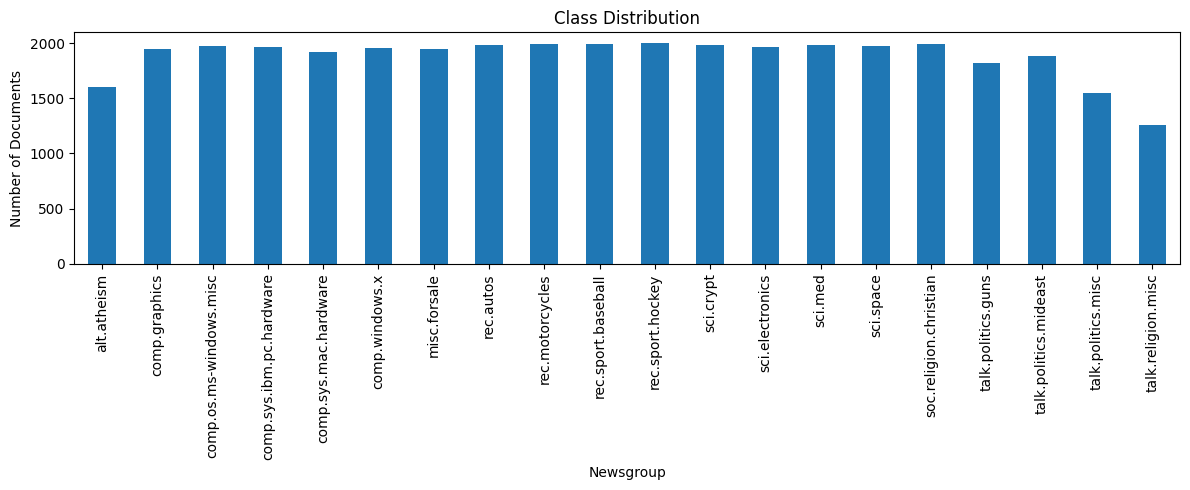

In [11]:
import matplotlib.pyplot as plt

# Plot number of documents per class
class_counts.plot(kind="bar", figsize=(12, 5))

plt.title("Class Distribution")
plt.xlabel("Newsgroup")
plt.ylabel("Number of Documents")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# 3. Baseline Model — ANN + TF-IDF

## 3.1 Text into numerical TF-IDF features
Text
 ↓
TF-IDF
 ↓
10,000 numerical features
 ↓
ANN

In [22]:
#Create TF-IDF Features
# Convert text into TF-IDF features
tfidf = TfidfVectorizer(
    max_features=10000,
    stop_words="english"
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

print("Train shape:", X_train_tfidf.shape)
print("Validation shape:", X_val_tfidf.shape)
print("Test shape:", X_test_tfidf.shape)

Train shape: (26363, 10000)
Validation shape: (5649, 10000)
Test shape: (5650, 10000)


In [23]:
#Encode the Labels
from sklearn.preprocessing import LabelEncoder

# Convert class names into numerical labels
label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_val_encoded = label_encoder.transform(y_val)
y_test_encoded = label_encoder.transform(y_test)

print("Classes:", label_encoder.classes_)

Classes: ['alt.atheism' 'comp.graphics' 'comp.os.ms-windows.misc'
 'comp.sys.ibm.pc.hardware' 'comp.sys.mac.hardware' 'comp.windows.x'
 'misc.forsale' 'rec.autos' 'rec.motorcycles' 'rec.sport.baseball'
 'rec.sport.hockey' 'sci.crypt' 'sci.electronics' 'sci.med' 'sci.space'
 'soc.religion.christian' 'talk.politics.guns' 'talk.politics.mideast'
 'talk.politics.misc' 'talk.religion.misc']


In [24]:
# Check final shapes before building the ANN
print("TF-IDF features:", X_train_tfidf.shape[1])
print("Number of classes:", len(label_encoder.classes_))
print("Training samples:", X_train_tfidf.shape[0])

TF-IDF features: 10000
Number of classes: 20
Training samples: 26363


## 3.2 ANN Input Preparation
Our TF-IDF matrices are sparse, while a basic ANN expects dense numerical input. Since we limited TF-IDF to 10,000 features, we can convert them to dense format.


In [25]:
# Convert TF-IDF matrices to dense arrays for the ANN
X_train_dense = X_train_tfidf.toarray()
X_val_dense = X_val_tfidf.toarray()
X_test_dense = X_test_tfidf.toarray()

print("Train shape:", X_train_dense.shape)
print("Validation shape:", X_val_dense.shape)
print("Test shape:", X_test_dense.shape)

Train shape: (26363, 10000)
Validation shape: (5649, 10000)
Test shape: (5650, 10000)


In [26]:
from tensorflow.keras.utils import to_categorical

# Convert class labels to one-hot format
num_classes = len(label_encoder.classes_)

y_train_cat = to_categorical(y_train_encoded, num_classes)
y_val_cat = to_categorical(y_val_encoded, num_classes)
y_test_cat = to_categorical(y_test_encoded, num_classes)

print("Label shape:", y_train_cat.shape)

Label shape: (26363, 20)


## 3.3 ANN Model

In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Build a simple ANN for 20-class classification
model = Sequential([
    Dense(128, activation="relu", input_shape=(X_train_dense.shape[1],)),
    Dropout(0.3),
    Dense(num_classes, activation="softmax")
])

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1791241827.588104      49 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1791241827.591515      49 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │     1,280,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 20)             │         2,580 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,282,708 (4.89 MB)

 Trainable params: 1,282,708 (4.89 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
# Configure the model for multi-class classification
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Train the ANN using the validation set for monitoring
history = model.fit(
    X_train_dense,
    y_train_cat,
    validation_data=(X_val_dense, y_val_cat),
    epochs=10,
    batch_size=32,
    verbose=1
)

# Evaluate the final model on unseen test data
test_loss, test_accuracy = model.evaluate(
    X_test_dense,
    y_test_cat,
    verbose=0
)

print("Test Accuracy:", round(test_accuracy, 4))

Epoch 1/10
 67/824 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1889 - loss: 2.9706

I0000 00:00:1791241912.042926     124 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


824/824 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.7773 - loss: 1.2692 - val_accuracy: 0.9065 - val_loss: 0.4374
Epoch 2/10
824/824 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9432 - loss: 0.2669 - val_accuracy: 0.9465 - val_loss: 0.2388
Epoch 3/10
824/824 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9774 - loss: 0.1158 - val_accuracy: 0.9568 - val_loss: 0.1762
Epoch 4/10
824/824 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9896 - loss: 0.0594 - val_accuracy: 0.9600 - val_loss: 0.1484
Epoch 5/10
824/824 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9954 - loss: 0.0335 - val_accuracy: 0.9632 - val_loss: 0.1383
Epoch 6/10
824/824 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9968 - loss: 0.0214 - val_accuracy: 0.9632 - val_loss: 0.1404
Epoch 7/10
824/824 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9979 - loss: 0.0142 - val_accuracy: 0.9625 - val_loss: 0.1422
Epoch 8/10
824/824 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9983 - loss: 0.0107 - val_accuracy: 0.9639 - val_

## 3.4 ANN Evaluation

In [22]:
# Generate predictions for the test set
y_pred_probs = model.predict(X_test_dense)

# Convert probabilities to predicted class labels
y_pred = np.argmax(y_pred_probs, axis=1)

print("Predictions generated:", len(y_pred))

# Test text → ANN → 20 probabilities → highest probability → predicted class

177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Predictions generated: 5650


In [27]:
# Test the classifier with new text
new_text = ["The hockey team did'nt won the game last night"]

# Convert text using the same TF-IDF vectorizer
new_text_tfidf = tfidf.transform(new_text)

# Convert to dense format
new_text_dense = new_text_tfidf.toarray()

# Predict the class
prediction_probs = model.predict(new_text_dense)
prediction = np.argmax(prediction_probs, axis=1)

print("Predicted newsgroup:", label_encoder.inverse_transform(prediction)[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Predicted newsgroup: rec.sport.hockey


In [23]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calculate classification metrics
accuracy = accuracy_score(y_test_encoded, y_pred)
precision = precision_score(y_test_encoded, y_pred, average="weighted")
recall = recall_score(y_test_encoded, y_pred, average="weighted")
f1 = f1_score(y_test_encoded, y_pred, average="weighted")

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-score :", round(f1, 4))

Accuracy : 0.9637
Precision: 0.9642
Recall   : 0.9637
F1-score : 0.9638


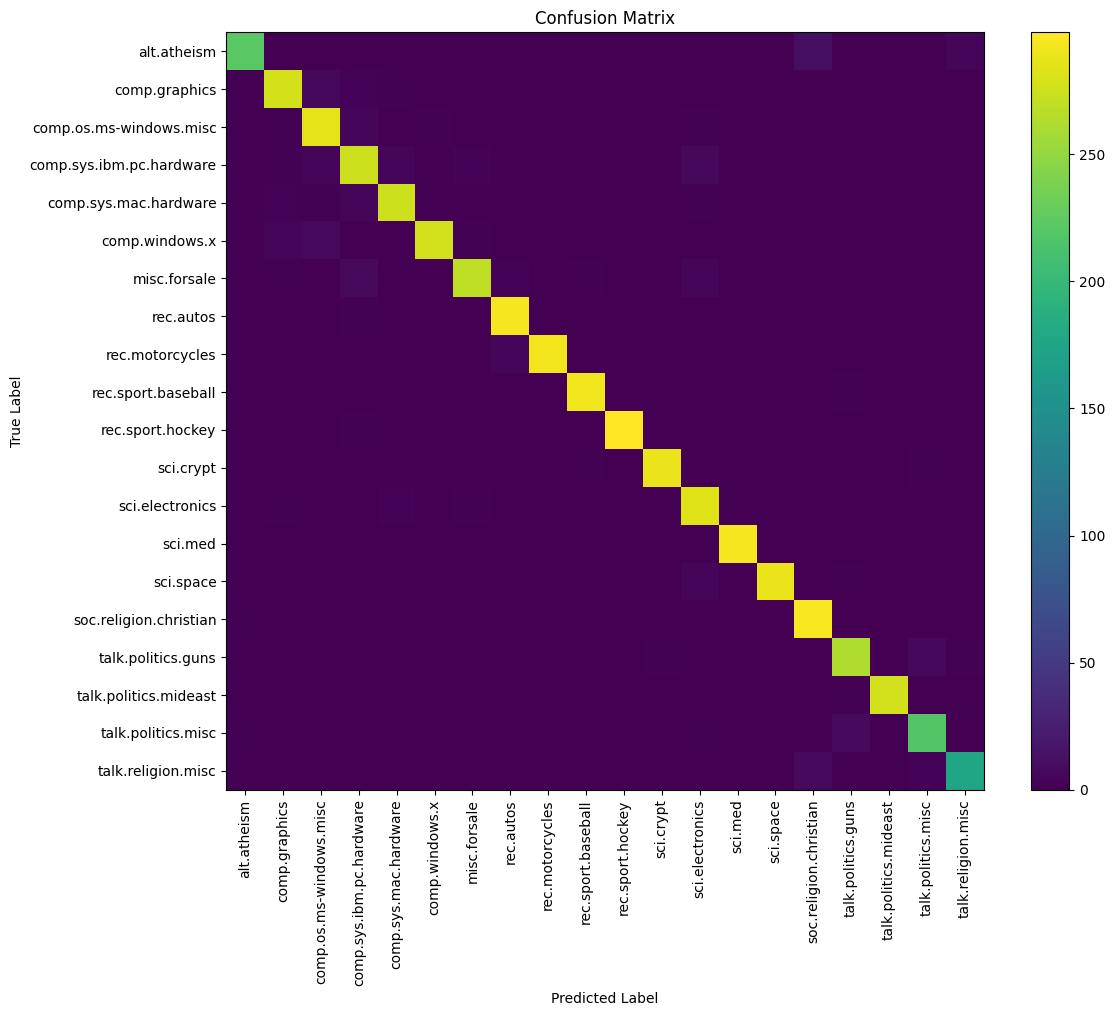

In [24]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Compute confusion matrix
cm = confusion_matrix(y_test_encoded, y_pred)

# Display confusion matrix
plt.figure(figsize=(12, 10))
plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()

plt.xticks(
    range(num_classes),
    label_encoder.classes_,
    rotation=90
)
plt.yticks(
    range(num_classes),
    label_encoder.classes_
)

plt.tight_layout()
plt.show()

# 4. 1D CNN
Text → Tokenization → Sequences → Embedding → 1D CNN
Because CNN needs sequences of tokens to detect local patterns such as phrases, we won't use the TF-IDF vectors from the ANN.

We'll keep it simple and only do what the assignment asks:
Text Tokenization & Padding
Build 1D CNN
Experiment with kernel sizes / filters
Train using validation set
Evaluate
Accuracy
Precision
Recall
F1-score
Confusion matrix

## 4.1 Tokenization & Sequence Preparation

In [29]:
# Tokenize text into integer sequences
max_words = 10000

tokenizer = Tokenizer(
    num_words=max_words,
    oov_token="<OOV>"
)

# Learn vocabulary only from training data
tokenizer.fit_on_texts(X_train)

# Convert text into integer sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)
X_test_seq = tokenizer.texts_to_sequences(X_test)

print("Training sequences:", len(X_train_seq))
print("Validation sequences:", len(X_val_seq))
print("Test sequences:", len(X_test_seq))

Training sequences: 26363
Validation sequences: 5649
Test sequences: 5650


In [30]:
# Check document sequence lengths
sequence_lengths = [len(seq) for seq in X_train_seq]

print("Minimum length:", min(sequence_lengths))
print("Maximum length:", max(sequence_lengths))
print("Average length:", np.mean(sequence_lengths))
print("Median length:", np.median(sequence_lengths))

Minimum length: 1
Maximum length: 20055
Average length: 207.90903918370444
Median length: 101.0


In [31]:
# Set a fixed sequence length
max_length = 300

# Pad sequences to the same length
X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

X_val_pad = pad_sequences(
    X_val_seq,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

print("Training shape:", X_train_pad.shape)
print("Validation shape:", X_val_pad.shape)
print("Test shape:", X_test_pad.shape)

# 300 = maximum sequence length
# 10,000 = maximum vocabulary size

Training shape: (26363, 300)
Validation shape: (5649, 300)
Test shape: (5650, 300)


## 4.2 Build 1D CNN
Token IDs → Embedding → Conv1D → MaxPooling → Dense → Output

In [34]:
# Number of words in the vocabulary
vocab_size = min(max_words, len(tokenizer.word_index) + 1)

# Build the 1D CNN model
cnn_model = Sequential([
    Input(shape=(max_length,)),

    Embedding(
        input_dim=vocab_size,
        output_dim=128
    ),

    Conv1D(
        filters=128,
        kernel_size=5,
        activation="relu"
    ),

    GlobalMaxPooling1D(),

    Dense(128, activation="relu"),
    Dropout(0.3),

    Dense(num_classes, activation="softmax")
])

cnn_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 300, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 296, 128)       │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 20)             │         2,580 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,381,140 (5.27 MB)

 Trainable params: 1,381,140 (5.27 MB)

 Non-trainable params: 0 (0.00 B)

What the numbers mean


* Embedding: 1,280,000 parameters → 10,000 words × 128-dimensional vectors.
* Conv1D: 82,048 parameters → 128 filters with kernel size 5.
* GlobalMaxPooling: 0 parameters → it only selects the strongest feature.
* Final Dense: (20,) → one output for each of your 20 newsgroup classes.
* Total: 1,381,140 trainable parameters.


In [36]:
# Compile the CNN
cnn_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [37]:
# Train the CNN
cnn_history = cnn_model.fit(
    X_train_pad,
    y_train_cat,
    validation_data=(X_val_pad, y_val_cat),
    epochs=10,
    batch_size=32,
    verbose=1
)

Epoch 1/10
824/824 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.5955 - loss: 1.3874 - val_accuracy: 0.8901 - val_loss: 0.3899
Epoch 2/10
824/824 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9403 - loss: 0.2195 - val_accuracy: 0.9487 - val_loss: 0.1894
Epoch 3/10
824/824 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9849 - loss: 0.0617 - val_accuracy: 0.9595 - val_loss: 0.1702
Epoch 4/10
824/824 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9945 - loss: 0.0266 - val_accuracy: 0.9649 - val_loss: 0.1692
Epoch 5/10
824/824 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9969 - loss: 0.0167 - val_accuracy: 0.9648 - val_loss: 0.1908
Epoch 6/10
824/824 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9978 - loss: 0.0139 - val_accuracy: 0.9625 - val_loss: 0.1930
Epoch 7/10
824/824 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9978 - loss: 0.0131 - val_accuracy: 0.9605 - val_loss: 0.2201
Epoch 8/10
824/824 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9959 - loss: 0.0198 - val_accuracy: 0

## 4.3 Diff Kernel Size and Filter Number

* Kernel sizes: 3, 5, 7
* Number of filters: 64, 128, 256



In [39]:
# Function to build a CNN with different kernel sizes and filter numbers
def build_cnn(kernel_size=5, filters=128):

    model = Sequential([
        Input(shape=(max_length,)),

        Embedding(
            input_dim=vocab_size,
            output_dim=128
        ),

        Conv1D(
            filters=filters,
            kernel_size=kernel_size,
            activation="relu"
        ),

        GlobalMaxPooling1D(),

        Dense(128, activation="relu"),
        Dropout(0.3),

        Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [40]:
# Test different kernel sizes
kernel_results = []

for kernel_size in [3, 5, 7]:

    print(f"\nTraining CNN with kernel size = {kernel_size}")

    model = build_cnn(
        kernel_size=kernel_size,
        filters=128
    )

    history = model.fit(
        X_train_pad,
        y_train_cat,
        validation_data=(X_val_pad, y_val_cat),
        epochs=10,
        batch_size=32,
        verbose=0
    )

    val_accuracy = max(history.history["val_accuracy"])

    kernel_results.append({
        "kernel_size": kernel_size,
        "filters": 128,
        "best_val_accuracy": val_accuracy
    })

kernel_results_df = pd.DataFrame(kernel_results)
kernel_results_df


Training CNN with kernel size = 3

Training CNN with kernel size = 5

Training CNN with kernel size = 7


,kernel_size,filters,best_val_accuracy
0,3,128,0.963179
1,5,128,0.965658
2,7,128,0.965304


In [41]:
# Test different numbers of filters
filter_results = []

for filters in [64, 128, 256]:

    print(f"\nTraining CNN with filters = {filters}")

    model = build_cnn(
        kernel_size=5,
        filters=filters
    )

    history = model.fit(
        X_train_pad,
        y_train_cat,
        validation_data=(X_val_pad, y_val_cat),
        epochs=10,
        batch_size=32,
        verbose=0
    )

    val_accuracy = max(history.history["val_accuracy"])

    filter_results.append({
        "kernel_size": 5,
        "filters": filters,
        "best_val_accuracy": val_accuracy
    })

filter_results_df = pd.DataFrame(filter_results)
filter_results_df


Training CNN with filters = 64

Training CNN with filters = 128

Training CNN with filters = 256


,kernel_size,filters,best_val_accuracy
0,5,64,0.958931
1,5,128,0.964064
2,5,256,0.963356


In [42]:
# Test all combinations of kernel sizes and filter numbers

kernel_sizes = [3, 5, 7]
filter_numbers = [64, 128, 256]

cnn_results = []
for kernel_size in kernel_sizes:
    for filters in filter_numbers:

        print(f"\nTraining: Kernel Size = {kernel_size}, Filters = {filters}")
        model = build_cnn(
            kernel_size=kernel_size,
            filters=filters
        )
        history = model.fit(
            X_train_pad,
            y_train_cat,
            validation_data=(X_val_pad, y_val_cat),
            epochs=10,
            batch_size=32,
            verbose=0
        )
        # Get the best validation accuracy
        best_val_accuracy = max(history.history["val_accuracy"])

        cnn_results.append({
            "kernel_size": kernel_size,
            "filters": filters,
            "best_val_accuracy": best_val_accuracy
        })
# Store all results in a table
cnn_results_df = pd.DataFrame(cnn_results)
cnn_results_df


Training: Kernel Size = 3, Filters = 64

Training: Kernel Size = 3, Filters = 128

Training: Kernel Size = 3, Filters = 256

Training: Kernel Size = 5, Filters = 64

Training: Kernel Size = 5, Filters = 128

Training: Kernel Size = 5, Filters = 256

Training: Kernel Size = 7, Filters = 64

Training: Kernel Size = 7, Filters = 128

Training: Kernel Size = 7, Filters = 256


,kernel_size,filters,best_val_accuracy
0,3,64,0.960170
1,3,128,0.962825
2,3,256,0.963710
3,5,64,0.967251
4,5,128,0.964773
5,5,256,0.961409
6,7,64,0.964064
7,7,128,0.967074
8,7,256,0.961940


## 4.4 CNN Evaluation

In [45]:
# Calculate classification metrics
accuracy = accuracy_score(y_test_encoded, y_pred)
precision = precision_score(
    y_test_encoded,
    y_pred,
    average="weighted"
)
recall = recall_score(
    y_test_encoded,
    y_pred,
    average="weighted"
)
f1 = f1_score(
    y_test_encoded,
    y_pred,
    average="weighted"
)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-score :", round(f1, 4))

Accuracy : 0.9623
Precision: 0.9626
Recall   : 0.9623
F1-score : 0.9623


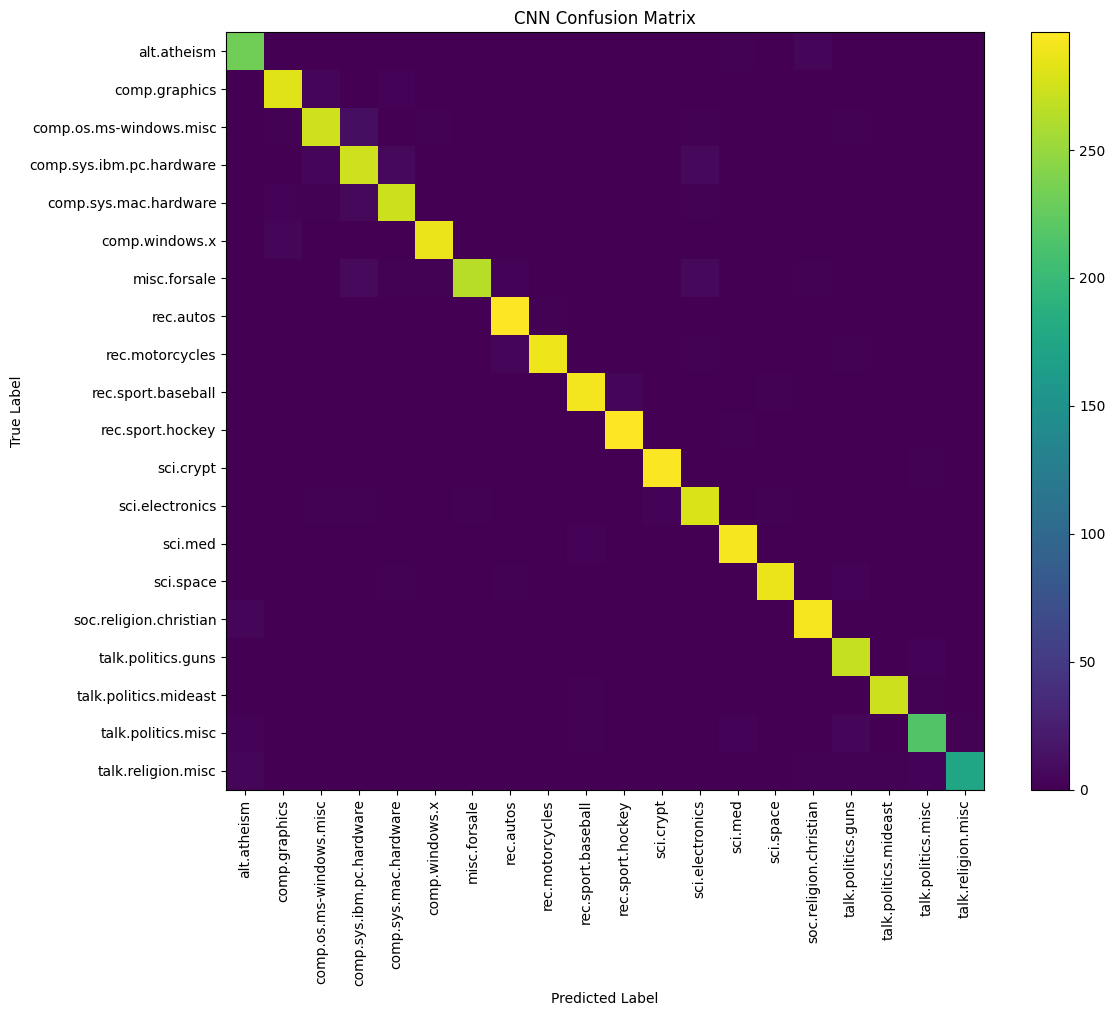

In [46]:
# Create confusion matrix
cm = confusion_matrix(y_test_encoded, y_pred)

plt.figure(figsize=(12, 10))
plt.imshow(cm)

plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()

plt.xticks(
    range(num_classes),
    label_encoder.classes_,
    rotation=90
)

plt.yticks(
    range(num_classes),
    label_encoder.classes_
)

plt.tight_layout()
plt.show()

# 5. RNNs

## 5.1 N-gram Feature Preparation
One important clarification before coding: for an RNN, an n-gram is normally a sequence of n consecutive tokens. Since the assignment specifically requires n=5, 10, 100, we'll use these as the sequence lengths fed to the RNN.

We already have tokenized sequences from Section 4.1, so we can reuse the tokenizer.

In [47]:
# Required n-gram sequence lengths
ngram_sizes = [5, 10, 100]

# Create padded sequences for each n-gram size
ngram_data = {}

for n in ngram_sizes:

    ngram_data[n] = {
        "train": pad_sequences(
            X_train_seq,
            maxlen=n,
            padding="post",
            truncating="post"
        ),
        
        "val": pad_sequences(
            X_val_seq,
            maxlen=n,
            padding="post",
            truncating="post"
        ),
        
        "test": pad_sequences(
            X_test_seq,
            maxlen=n,
            padding="post",
            truncating="post"
        )
    }

    print(f"n={n}")
    print("  Train:", ngram_data[n]["train"].shape)
    print("  Val  :", ngram_data[n]["val"].shape)
    print("  Test :", ngram_data[n]["test"].shape)

n=5
  Train: (26363, 5)
  Val  : (5649, 5)
  Test : (5650, 5)
n=10
  Train: (26363, 10)
  Val  : (5649, 10)
  Test : (5650, 10)
n=100
  Train: (26363, 100)
  Val  : (5649, 100)
  Test : (5650, 100)


## 5.2 Simple RNN

In [48]:
# Function to build a Simple RNN model
def build_rnn(sequence_length):

    model = Sequential([
        Input(shape=(sequence_length,)),

        Embedding(
            input_dim=vocab_size,
            output_dim=128
        ),

        SimpleRNN(128),

        Dense(128, activation="relu"),
        Dropout(0.3),

        Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

This is a good example of why basic RNNs can struggle with long sequences. As the sequence becomes longer, the RNN has to carry information through many time steps, making it harder to preserve useful information.

## 5.3 GRU

In [50]:
# Function to build a GRU model
def build_gru(sequence_length):

    model = Sequential([
        Input(shape=(sequence_length,)),

        Embedding(
            input_dim=vocab_size,
            output_dim=128
        ),

        GRU(128),

        Dense(128, activation="relu"),
        Dropout(0.3),

        Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

## 5.4 LSTM.

In [52]:
# Function to build an LSTM model
def build_lstm(sequence_length):

    model = Sequential([
        Input(shape=(sequence_length,)),

        Embedding(
            input_dim=vocab_size,
            output_dim=128
        ),

        LSTM(128),

        Dense(128, activation="relu"),
        Dropout(0.3),

        Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

## 5.5 BiLSTM
A Bidirectional LSTM processes the sequence in both directions:

Forward: beginning → end
Backward: end → beginning
This allows the model to use context from both sides of a word.

In [54]:
# Function to build a Bidirectional LSTM model
def build_bilstm(sequence_length):

    model = Sequential([
        Input(shape=(sequence_length,)),

        Embedding(
            input_dim=vocab_size,
            output_dim=128
        ),

        Bidirectional(
            LSTM(128)
        ),

        Dense(128, activation="relu"),
        Dropout(0.3),

        Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

## 5.6 BiGRU

In [56]:
# Function to build a Bidirectional GRU model
def build_bigru(sequence_length):

    model = Sequential([
        Input(shape=(sequence_length,)),

        Embedding(
            input_dim=vocab_size,
            output_dim=128
        ),
        Bidirectional(
            GRU(128)
        ),

        Dense(128, activation="relu"),
        Dropout(0.3),
        Dense(num_classes, activation="softmax")
    ])
    model.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

## 5.7 RNN Evaluation 

In [58]:
# 5.7 Evaluate all RNN models with n=5, 10, 100

rnn_builders = {
    "Simple RNN": build_rnn,
    "GRU": build_gru,
    "LSTM": build_lstm,
    "BiLSTM": build_bilstm,
    "BiGRU": build_bigru
}

rnn_eval_results = []
rnn_confusion_matrices = {}

for model_name, builder in rnn_builders.items():
    for n in ngram_sizes:

        print(f"Training {model_name} with n={n}...")

        # Clear previous model from memory
        tf.keras.backend.clear_session()
        # Build model
        model = builder(n)

        # Train model
        model.fit(
            ngram_data[n]["train"],
            y_train_cat,
            validation_data=(
                ngram_data[n]["val"],
                y_val_cat
            ),
            epochs=10,
            batch_size=32,
            verbose=0
        )
        # Predictions
        y_pred_probs = model.predict(
            ngram_data[n]["test"],
            verbose=0
        )
        y_pred = np.argmax(y_pred_probs, axis=1)

        # Metrics
        accuracy = accuracy_score(y_test_encoded, y_pred)
        precision = precision_score(
            y_test_encoded,
            y_pred,
            average="weighted"
        )
        recall = recall_score(
            y_test_encoded,
            y_pred,
            average="weighted"
        )
        f1 = f1_score(
            y_test_encoded,
            y_pred,
            average="weighted"
        )
        # Confusion matrix
        cm = confusion_matrix(
            y_test_encoded,
            y_pred
        )
        # Save metrics
        rnn_eval_results.append({
            "Model": model_name,
            "n": n,
            "Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall,
            "F1": f1
        })
        # Save confusion matrix
        rnn_confusion_matrices[f"{model_name} - n={n}"] = cm
        print(
            f"Accuracy: {accuracy:.4f} | "
            f"Precision: {precision:.4f} | "
            f"Recall: {recall:.4f} | "
            f"F1: {f1:.4f}"
        )
# Convert results to DataFrame
rnn_eval_df = pd.DataFrame(rnn_eval_results)

rnn_eval_df

Training Simple RNN with n=5...
Accuracy: 0.9177 | Precision: 0.9193 | Recall: 0.9177 | F1: 0.9180
Training Simple RNN with n=10...
Accuracy: 0.9276 | Precision: 0.9294 | Recall: 0.9276 | F1: 0.9280
Training Simple RNN with n=100...
Accuracy: 0.1550 | Precision: 0.1912 | Recall: 0.1550 | F1: 0.1386
Training GRU with n=5...
Accuracy: 0.9205 | Precision: 0.9222 | Recall: 0.9205 | F1: 0.9208
Training GRU with n=10...
Accuracy: 0.9265 | Precision: 0.9281 | Recall: 0.9265 | F1: 0.9269
Training GRU with n=100...
Accuracy: 0.9542 | Precision: 0.9548 | Recall: 0.9542 | F1: 0.9542
Training LSTM with n=5...
Accuracy: 0.9205 | Precision: 0.9230 | Recall: 0.9205 | F1: 0.9209
Training LSTM with n=10...
Accuracy: 0.9359 | Precision: 0.9365 | Recall: 0.9359 | F1: 0.9360
Training LSTM with n=100...
Accuracy: 0.9480 | Precision: 0.9484 | Recall: 0.9480 | F1: 0.9480
Training BiLSTM with n=5...
Accuracy: 0.9251 | Precision: 0.9259 | Recall: 0.9251 | F1: 0.9252
Training BiLSTM with n=10...
Accuracy: 0.937

,Model,n,Accuracy,Precision,Recall,F1
0,Simple RNN,5,0.917699,0.919289,0.917699,0.917967
1,Simple RNN,10,0.927611,0.929398,0.927611,0.928003
2,Simple RNN,100,0.155044,0.191182,0.155044,0.138627
3,GRU,5,0.920531,0.922248,0.920531,0.920815
4,GRU,10,0.926549,0.928123,0.926549,0.926852
5,GRU,100,0.954159,0.954756,0.954159,0.954154
6,LSTM,5,0.920531,0.923012,0.920531,0.920944
7,LSTM,10,0.935929,0.936460,0.935929,0.935998
8,LSTM,100,0.947965,0.948378,0.947965,0.948000
9,BiLSTM,5,0.925133,0.925888,0.925133,0.925215


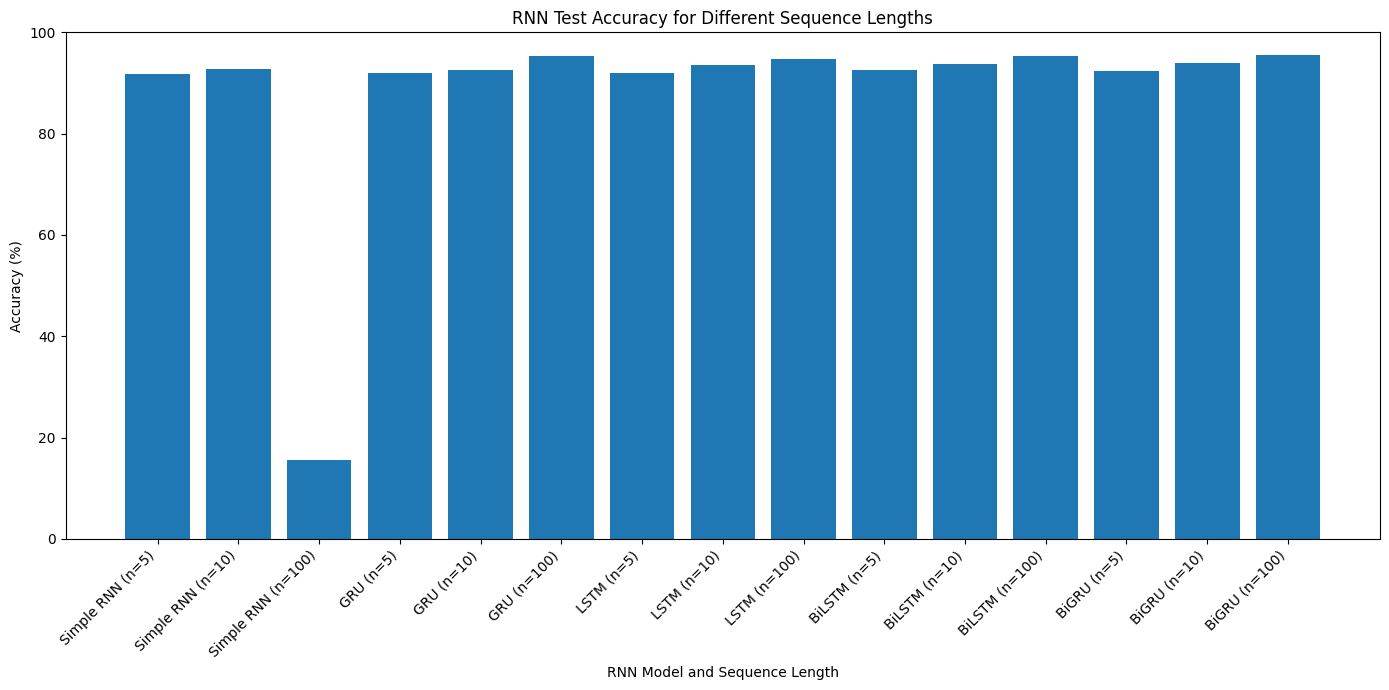

In [60]:
# Visualize RNN test results

plt.figure(figsize=(14, 7))

# Create configuration labels
rnn_eval_df["Configuration"] = (
    rnn_eval_df["Model"] +
    " (n=" +
    rnn_eval_df["n"].astype(str) +
    ")"
)

# Plot accuracy
plt.bar(
    rnn_eval_df["Configuration"],
    rnn_eval_df["Accuracy"] * 100
)

plt.xlabel("RNN Model and Sequence Length")
plt.ylabel("Accuracy (%)")
plt.title("RNN Test Accuracy for Different Sequence Lengths")

plt.xticks(rotation=45, ha="right")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

# 6. Incorporating Pre-trained Embeddings

In [61]:
# Check required libraries

import gensim
import transformers
import torch

print("Gensim:", gensim.__version__)
print("Transformers:", transformers.__version__)
print("PyTorch:", torch.__version__)

Gensim: 4.4.0
Transformers: 5.16.1
PyTorch: 2.11.0+cu128


In [62]:
import gensim.downloader as api

print(api.info()["models"].keys())

dict_keys(['fasttext-wiki-news-subwords-300', 'conceptnet-numberbatch-17-06-300', 'word2vec-ruscorpora-300', 'word2vec-google-news-300', 'glove-wiki-gigaword-50', 'glove-wiki-gigaword-100', 'glove-wiki-gigaword-200', 'glove-wiki-gigaword-300', 'glove-twitter-25', 'glove-twitter-50', 'glove-twitter-100', 'glove-twitter-200', '__testing_word2vec-matrix-synopsis'])


## 6.1 BERT setup

In [ ]:
# 6.1 Load pre-trained FastText

import gensim.downloader as api

fasttext_model = api.load("fasttext-wiki-news-subwords-300")

print("FastText loaded successfully")
print("Embedding dimension:", fasttext_model.vector_size)

[--------------------------------------------------] 0.8% 7.3/958.4MB downloaded

In [ ]:
# 6.2 Load pre-trained Word2Vec
import gensim.downloader as api
word2vec_model = api.load("word2vec-google-news-300")

print("Word2Vec loaded successfully")
print("Embedding dimension:", word2vec_model.vector_size)

[--------------------------------------------------] 0.0% 0.0/1662.8MB downloaded

In [3]:
# 6.1 BERT Setup

from transformers import BertTokenizer, BertModel
import torch
import numpy as np

# Load pre-trained BERT tokenizer
bert_tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

# Load pre-trained BERT
bert_model = BertModel.from_pretrained("bert-base-uncased")

# Freeze BERT weights
for param in bert_model.parameters():
    param.requires_grad = False

# Use BERT only as a feature extractor
bert_model.eval()

# Maximum number of tokens per document
bert_max_length = 64

print("BERT ready")
print("Hidden size:", bert_model.config.hidden_size)
print("Maximum sequence length:", bert_max_length)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERT ready
Hidden size: 768
Maximum sequence length: 64


### 6.1.1 BERT Tokenization

In [13]:
# 6.2 BERT Tokenization

def tokenize_for_bert(texts):
    return bert_tokenizer(
        texts.tolist(),
        padding="max_length",
        truncation=True,
        max_length=bert_max_length,
        return_tensors="pt"
    )

bert_train = tokenize_for_bert(X_train)
bert_val = tokenize_for_bert(X_val)
bert_test = tokenize_for_bert(X_test)

print("Train:", bert_train["input_ids"].shape)
print("Validation:", bert_val["input_ids"].shape)
print("Test:", bert_test["input_ids"].shape)

Train: torch.Size([26363, 64])
Validation: torch.Size([5649, 64])
Test: torch.Size([5650, 64])


Here:

input_ids → token IDs understood by BERT
attention_mask → tells BERT which positions are real tokens vs padding
64 → maximum tokens per document

Next: we'll pass these tokens through frozen BERT and extract its 768-dimensional representations.

### 6.1.2 Extract BERT Representations

Now we pass the tokenized text through the frozen BERT model.
We'll extract the [CLS] representation, which gives one 768-dimensional vector per document. This is ideal for our ANN.

In [14]:
# Extract BERT [CLS] representations

def extract_bert_features(encoded_data, batch_size=16):
    features = []

    input_ids = encoded_data["input_ids"]
    attention_mask = encoded_data["attention_mask"]

    with torch.no_grad():
        for i in range(0, len(input_ids), batch_size):

            batch_ids = input_ids[i:i + batch_size]
            batch_mask = attention_mask[i:i + batch_size]

            outputs = bert_model(
                input_ids=batch_ids,
                attention_mask=batch_mask
            )

            # [CLS] representation
            cls_features = outputs.last_hidden_state[:, 0, :]

            features.append(cls_features.cpu().numpy())

    return np.concatenate(features, axis=0)


bert_train_features = extract_bert_features(bert_train)
bert_val_features = extract_bert_features(bert_val)
bert_test_features = extract_bert_features(bert_test)

print("Train features:", bert_train_features.shape)
print("Validation features:", bert_val_features.shape)
print("Test features:", bert_test_features.shape)

# So now each document is represented as:
# Text → BERT → 768-dimensional vector

Train features: (26363, 768)
Validation features: (5649, 768)
Test features: (5650, 768)


## 6.2 ANN + BERT

In [18]:
# Number of output classes
num_classes = len(label_encoder.classes_)

print("Number of classes:", num_classes)

Number of classes: 20


In [28]:
# 6.3 ANN + BERT

ann_bert = Sequential([
    Input(shape=(768,)),
    Dense(128, activation="relu"),
    Dropout(0.3),
    Dense(num_classes, activation="softmax")
])

ann_bert.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

ann_bert_history = ann_bert.fit(
    bert_train_features,
    y_train_cat,
    validation_data=(
        bert_val_features,
        y_val_cat
    ),
    epochs=10,
    batch_size=32,
    verbose=1
)

Epoch 1/10
824/824 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.5380 - loss: 1.4389 - val_accuracy: 0.6576 - val_loss: 1.0235
Epoch 2/10
824/824 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6603 - loss: 1.0219 - val_accuracy: 0.6946 - val_loss: 0.9123
Epoch 3/10
824/824 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6955 - loss: 0.9251 - val_accuracy: 0.7134 - val_loss: 0.8552
Epoch 4/10
824/824 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7141 - loss: 0.8571 - val_accuracy: 0.7320 - val_loss: 0.8088
Epoch 5/10
824/824 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7309 - loss: 0.8051 - val_accuracy: 0.7465 - val_loss: 0.7640
Epoch 6/10
824/824 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7486 - loss: 0.7546 - val_accuracy: 0.7460 - val_loss: 0.7660
Epoch 7/10
824/824 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7562 - loss: 0.7264 - val_accuracy: 0.7486 - val_loss: 0.7468
Epoch 8/10
824/824 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7682 - loss: 0.6910 - val_accuracy: 0.

### 6.2.1 A+B evaluation 

Accuracy:  0.7738
Precision: 0.7790
Recall:    0.7738
F1 Score:  0.7737


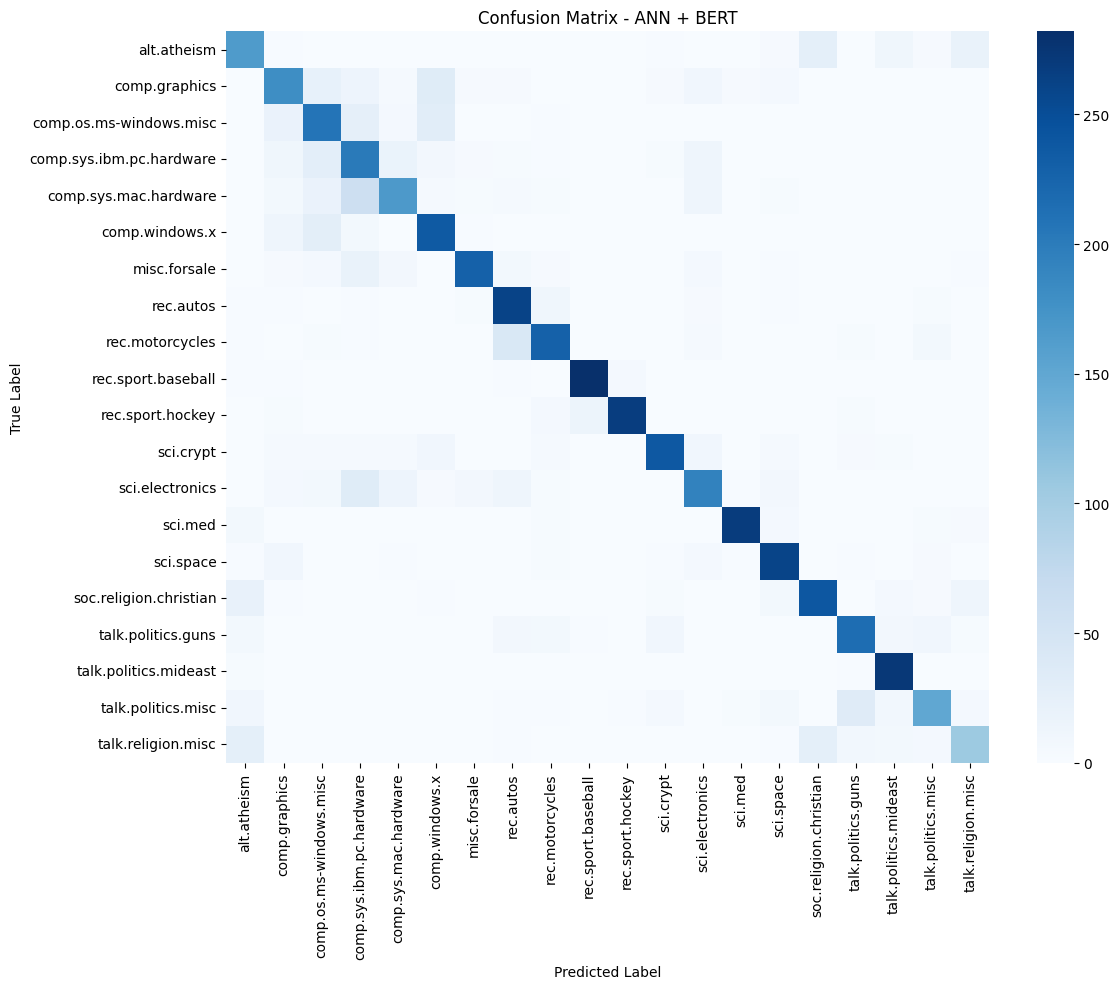

In [29]:
# Evaluate ANN + BERT

y_pred_probs = ann_bert.predict(
    bert_test_features,
    verbose=0
)

y_pred = np.argmax(y_pred_probs, axis=1)

accuracy = accuracy_score(y_test_encoded, y_pred)
precision = precision_score(y_test_encoded, y_pred, average="weighted")
recall = recall_score(y_test_encoded, y_pred, average="weighted")
f1 = f1_score(y_test_encoded, y_pred, average="weighted")

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

cm_ann_bert = confusion_matrix(y_test_encoded, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm_ann_bert,
    annot=False,
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - ANN + BERT")
plt.tight_layout()
plt.show()

## 6.3 CNN+BERT: Extract token representations
Yes. For CNN + BERT, we'll reuse the same BERT representations. We don't need to tokenize or extract BERT features again.

One important difference: ANN used the 768-dimensional [CLS] document vector. For CNN, we need the sequence of BERT token representations, because CNN is supposed to learn local patterns across tokens.

So first, we need to extract and store BERT's full last_hidden_state.

In [30]:
# Extract full BERT token representations for CNN

def extract_bert_sequence_features(encoded_data, batch_size=16):
    features = []

    input_ids = encoded_data["input_ids"]
    attention_mask = encoded_data["attention_mask"]

    with torch.no_grad():
        for i in range(0, len(input_ids), batch_size):

            batch_ids = input_ids[i:i + batch_size]
            batch_mask = attention_mask[i:i + batch_size]

            outputs = bert_model(
                input_ids=batch_ids,
                attention_mask=batch_mask
            )

            # Keep representations for all tokens
            sequence_features = outputs.last_hidden_state

            features.append(sequence_features.cpu().numpy())

    return np.concatenate(features, axis=0)


bert_train_sequence = extract_bert_sequence_features(bert_train)
bert_val_sequence = extract_bert_sequence_features(bert_val)
bert_test_sequence = extract_bert_sequence_features(bert_test)

print("Train:", bert_train_sequence.shape)
print("Validation:", bert_val_sequence.shape)
print("Test:", bert_test_sequence.shape)

# Then the CNN will operate on:
#BERT token representations → Conv1D → GlobalMaxPooling → Dense → 20 classes


Train: (26363, 64, 768)
Validation: (5649, 64, 768)
Test: (5650, 64, 768)


### 6.3.1 CNN + BERT: Build and Train
Cleaned Text
      ↓
Frozen Pre-trained BERT
      ↓
64 tokens × 768 features
      ↓
Conv1D
      ↓
Global Max Pooling
      ↓
Dense
      ↓
20-class prediction

In [31]:
# CNN using BERT token representations

cnn_bert = Sequential([
    Input(shape=(bert_max_length, 768)),
    Conv1D(
        filters=128,
        kernel_size=5,
        activation="relu"
    ),
    GlobalMaxPooling1D(),
    Dense(128, activation="relu"),
    Dropout(0.3),
    Dense(num_classes, activation="softmax")
])

cnn_bert.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_bert.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 60, 128)        │       491,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 20)             │         2,580 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 510,740 (1.95 MB)

 Trainable params: 510,740 (1.95 MB)

 Non-trainable params: 0 (0.00 B)

In [34]:
# Train CNN + BERT

cnn_bert_history = cnn_bert.fit(
    bert_train_sequence,
    y_train_cat,
    validation_data=(
        bert_val_sequence,
        y_val_cat
    ),
    epochs=10,
    batch_size=32,
    verbose=1
)

Epoch 1/10
824/824 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9844 - loss: 0.0494 - val_accuracy: 0.9430 - val_loss: 0.2989
Epoch 2/10
824/824 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9873 - loss: 0.0389 - val_accuracy: 0.9549 - val_loss: 0.2780
Epoch 3/10
824/824 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9846 - loss: 0.0482 - val_accuracy: 0.9550 - val_loss: 0.2845
Epoch 4/10
824/824 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9866 - loss: 0.0445 - val_accuracy: 0.9334 - val_loss: 0.3845
Epoch 5/10
824/824 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9877 - loss: 0.0406 - val_accuracy: 0.9524 - val_loss: 0.3013
Epoch 6/10
824/824 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9879 - loss: 0.0391 - val_accuracy: 0.9559 - val_loss: 0.3099
Epoch 7/10
824/824 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9890 - loss: 0.0367 - val_accuracy: 0.9570 - val_loss: 0.3167
Epoch 8/10
824/824 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9897 - loss: 0.0341 - val_accuracy: 0

### 6.3.2 C+B evaluation 

In [35]:
# Evaluate CNN + BERT

y_pred_probs = cnn_bert.predict(
    bert_test_sequence,
    verbose=0
)

y_pred = np.argmax(y_pred_probs, axis=1)

accuracy = accuracy_score(y_test_encoded, y_pred)
precision = precision_score(
    y_test_encoded,
    y_pred,
    average="weighted"
)
recall = recall_score(
    y_test_encoded,
    y_pred,
    average="weighted"
)
f1 = f1_score(
    y_test_encoded,
    y_pred,
    average="weighted"
)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

Accuracy:  0.9540
Precision: 0.9554
Recall:    0.9540
F1 Score:  0.9542


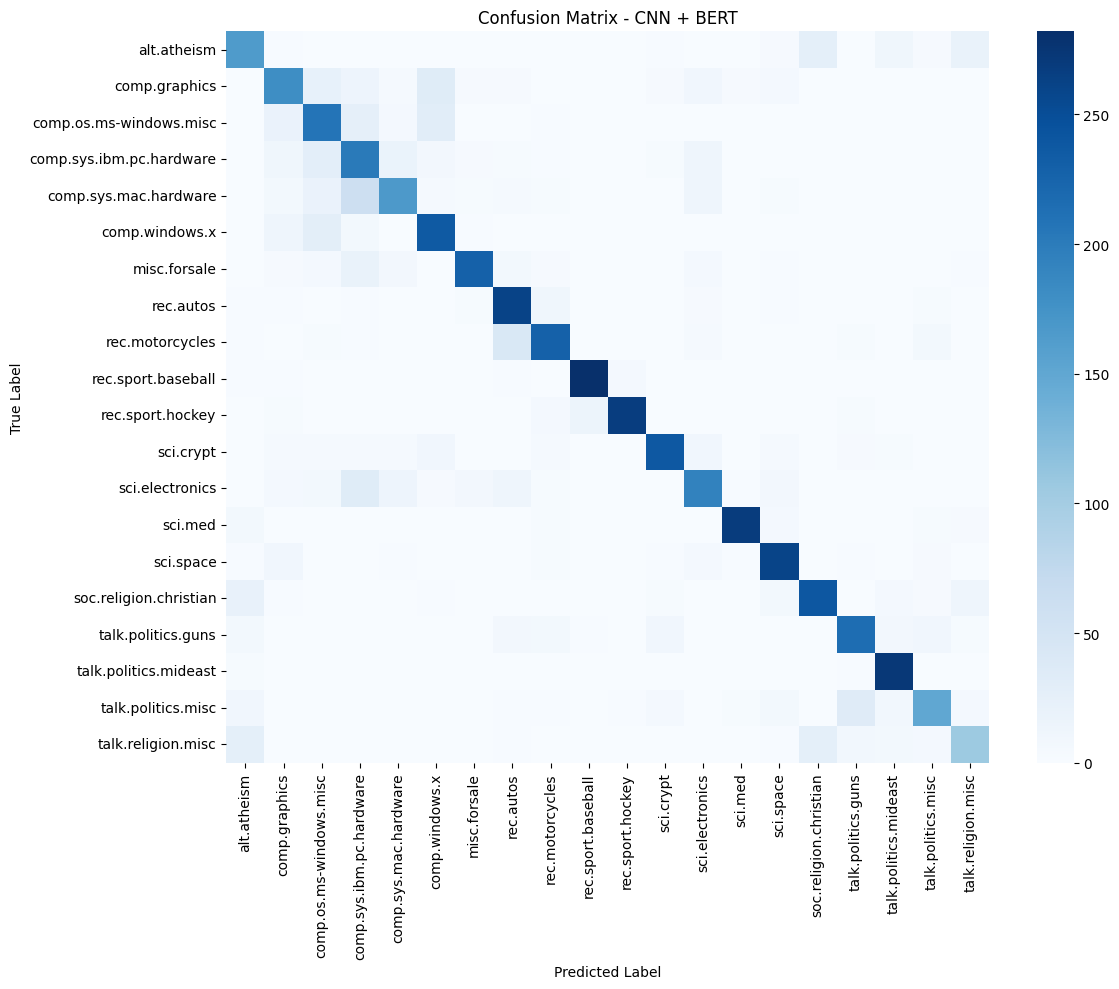

In [33]:
# Confusion matrix - CNN + BERT

cm_cnn_bert = confusion_matrix(
    y_test_encoded,
    y_pred
)

plt.figure(figsize=(12, 10))

sns.heatmap(
    cm_cnn_bert,
    annot=False,
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - CNN + BERT")
plt.tight_layout()
plt.show()

## 6.4 Simple RNN + BERT
Since we already extracted the BERT token representations, we can reuse them directly.

Input shape:
(64 tokens, 768 BERT features)

In [36]:
# Simple RNN using BERT token representations

rnn_bert = Sequential([
    Input(shape=(bert_max_length, 768)),
    SimpleRNN(128),
    Dense(128, activation="relu"),
    Dropout(0.3),
    Dense(num_classes, activation="softmax")
])

rnn_bert.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

rnn_bert.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 128)            │       114,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 20)             │         2,580 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 133,908 (523.08 KB)

 Trainable params: 133,908 (523.08 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
# Train Simple RNN + BERT

rnn_bert_history = rnn_bert.fit(
    bert_train_sequence,
    y_train_cat,
    validation_data=(
        bert_val_sequence,
        y_val_cat
    ),
    epochs=10,
    batch_size=32,
    verbose=1
)

Epoch 1/10
824/824 ━━━━━━━━━━━━━━━━━━━━ 15s 16ms/step - accuracy: 0.4606 - loss: 1.6286 - val_accuracy: 0.6245 - val_loss: 1.1342
Epoch 2/10
824/824 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.6407 - loss: 1.0721 - val_accuracy: 0.6741 - val_loss: 0.9704
Epoch 3/10
824/824 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.7049 - loss: 0.8764 - val_accuracy: 0.7017 - val_loss: 0.9007
Epoch 4/10
824/824 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.7536 - loss: 0.7339 - val_accuracy: 0.7097 - val_loss: 0.8911
Epoch 5/10
824/824 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.7924 - loss: 0.6087 - val_accuracy: 0.7518 - val_loss: 0.7788
Epoch 6/10
824/824 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.8284 - loss: 0.5106 - val_accuracy: 0.7780 - val_loss: 0.7087
Epoch 7/10
824/824 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.8523 - loss: 0.4387 - val_accuracy: 0.7934 - val_loss: 0.7014
Epoch 8/10
824/824 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.8738 - loss: 0.3681 - val_acc

Cleaned Text
      ↓
Frozen BERT
      ↓
64 × 768 token representations
      ↓
Simple RNN
      ↓
Dense
      ↓
20-class prediction

### 6.4.1 R+B evaluation 

In [38]:
# Evaluate Simple RNN + BERT

y_pred_probs = rnn_bert.predict(
    bert_test_sequence,
    verbose=0
)

y_pred = np.argmax(y_pred_probs, axis=1)

accuracy = accuracy_score(y_test_encoded, y_pred)
precision = precision_score(
    y_test_encoded,
    y_pred,
    average="weighted"
)
recall = recall_score(
    y_test_encoded,
    y_pred,
    average="weighted"
)
f1 = f1_score(
    y_test_encoded,
    y_pred,
    average="weighted"
)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

Accuracy:  0.8209
Precision: 0.8302
Recall:    0.8209
F1 Score:  0.8199


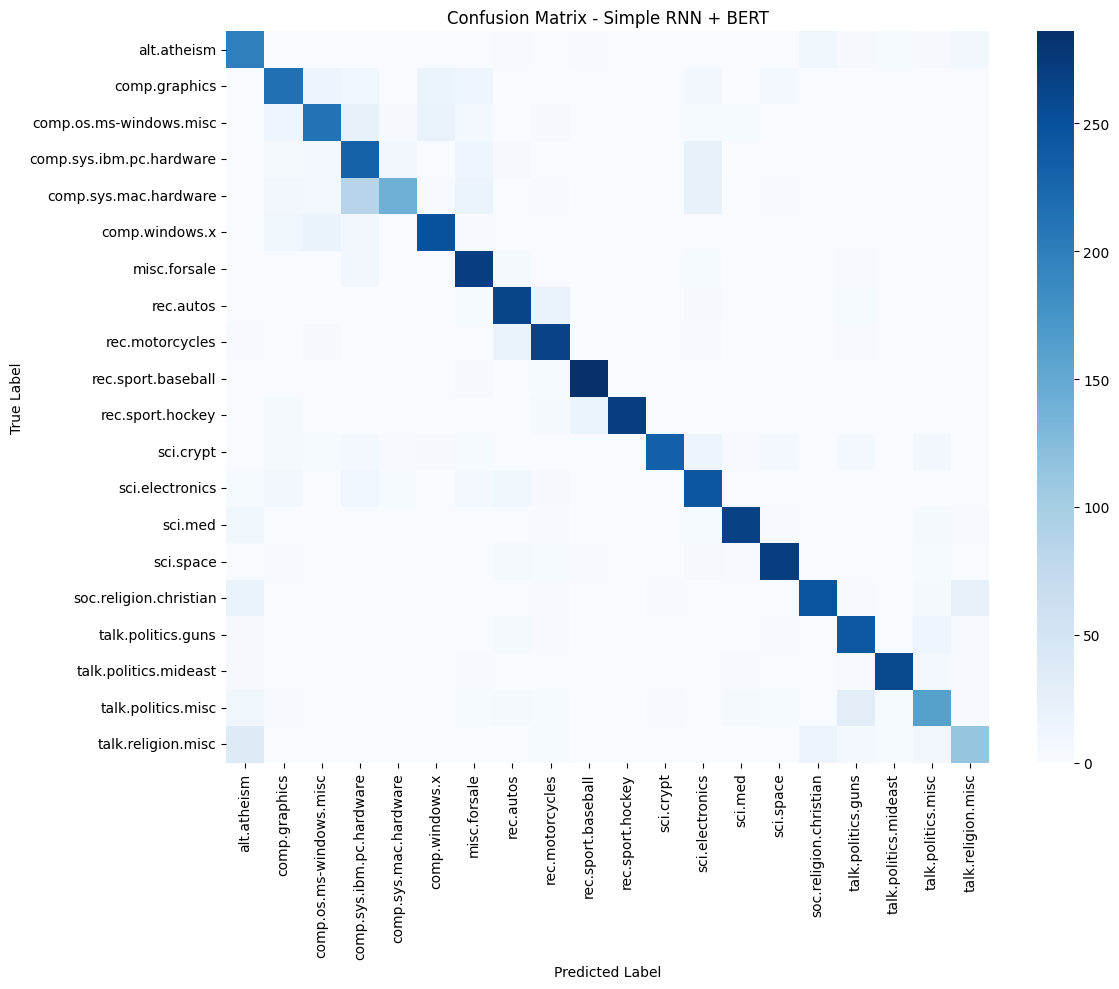

In [39]:
# Confusion matrix - Simple RNN + BERT

cm_rnn_bert = confusion_matrix(
    y_test_encoded,
    y_pred
)

plt.figure(figsize=(12, 10))

sns.heatmap(
    cm_rnn_bert,
    annot=False,
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Simple RNN + BERT")
plt.tight_layout()
plt.show()

# 7. Transformer-based Model(finetuning BERT)
Section 7 will demonstrate the important difference between using a pre-trained model as a feature extractor and fine-tuning the pre-trained model for your specific task.

Cleaned text
    ↓
BERT tokenizer
    ↓
Pre-trained BERT
    ↓
Fine-tune BERT on 20 Newsgroups
    ↓
Classification head
    ↓
20 classes
    ↓
Accuracy / Precision / Recall / F1
    ↓
Confusion Matrix

## 7.1 Load BERT for Classification
You may see a message saying that the classification layer is newly initialized. That's expected.

Why?

BERT's original pre-trained layers already have learned weights.
The final classification layer for your 20 newsgroup classes is new.
During fine-tuning, both BERT and this classification layer will learn from your dataset.

In [40]:
# 7.1 Fine-tuned BERT for Text Classification

from transformers import BertTokenizer, BertForSequenceClassification

# Load BERT tokenizer
finetune_tokenizer = BertTokenizer.from_pretrained(
    "bert-base-uncased"
)

# Load BERT with a classification head
finetune_model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=num_classes
)

print("BERT classification model loaded")
print("Number of classes:", num_classes)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BERT classification model loaded
Number of classes: 20


The important lines are:

classifier.weight → MISSING
classifier.bias   → MISSING

That's because bert-base-uncased was originally pretrained as a general language model, not specifically for your 20-class newsgroup classification. So Transformers creates a new classification layer for your 20 classes.

The UNEXPECTED keys are the original BERT pretraining head, which BertForSequenceClassification doesn't need. They can be ignored.

So your model is correctly loaded:
Pre-trained BERT encoder
        ↓
New 20-class classification head
        ↓
Fine-tuning on your dataset

## 7.2 Tokenization
We'll tokenize the same cleaned X_train, X_val, and X_test

In [41]:
# 7.2 Tokenize text for fine-tuning BERT

def tokenize_for_finetuning(texts):
    return finetune_tokenizer(
        texts.tolist(),
        padding="max_length",
        truncation=True,
        max_length=128,
        return_tensors="pt"
    )

finetune_train = tokenize_for_finetuning(X_train)
finetune_val = tokenize_for_finetuning(X_val)
finetune_test = tokenize_for_finetuning(X_test)

print("Train:", finetune_train["input_ids"].shape)
print("Validation:", finetune_val["input_ids"].shape)
print("Test:", finetune_test["input_ids"].shape)

# We use 128 tokens here rather than 64 because fine-tuning BERT directly
#can benefit from a little more text context.

Train: torch.Size([26363, 128])
Validation: torch.Size([5649, 128])
Test: torch.Size([5650, 128])


## 7.3 Prepare PyTorch Dataset
BERT's fine-tuning model expects PyTorch tensors, so we'll combine the tokenized inputs with the encoded labels.

In [42]:
# 7.3 Prepare datasets for BERT fine-tuning

from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(
    finetune_train["input_ids"],
    finetune_train["attention_mask"],
    torch.tensor(y_train_encoded)
)

val_dataset = TensorDataset(
    finetune_val["input_ids"],
    finetune_val["attention_mask"],
    torch.tensor(y_val_encoded)
)

test_dataset = TensorDataset(
    finetune_test["input_ids"],
    finetune_test["attention_mask"],
    torch.tensor(y_test_encoded)
)

print("Train samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Test samples:", len(test_dataset))

Train samples: 26363
Validation samples: 5649
Test samples: 5650


## 7.4 GPU and DataLoaders

In [43]:
# 7.4 Setup device and DataLoaders

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

# Move BERT to GPU/CPU
finetune_model = finetune_model.to(device)

# DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False
)

print("DataLoaders ready")

Using device: cuda
DataLoaders ready


## 7.5 Optimizer

In [44]:
# 7.5 Optimizer for BERT fine-tuning

from torch.optim import AdamW

optimizer = AdamW(
    finetune_model.parameters(),
    lr=2e-5
)

print("Optimizer ready")

Optimizer ready


## 7.6 Fine-tune BERT

In [45]:
# 7.6 Fine-tune BERT

epochs = 3

for epoch in range(epochs):

    # -------------------------
    # Training
    # -------------------------
    finetune_model.train()

    total_train_loss = 0
    correct_train = 0
    total_train = 0

    for input_ids, attention_mask, labels in train_loader:

        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = finetune_model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        logits = outputs.logits

        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

        predictions = torch.argmax(logits, dim=1)
        correct_train += (predictions == labels).sum().item()
        total_train += labels.size(0)

    train_loss = total_train_loss / len(train_loader)
    train_accuracy = correct_train / total_train

    # -------------------------
    # Validation
    # -------------------------
    finetune_model.eval()

    total_val_loss = 0
    correct_val = 0
    total_val = 0

    with torch.no_grad():

        for input_ids, attention_mask, labels in val_loader:

            input_ids = input_ids.to(device)
            attention_mask = attention_mask.to(device)
            labels = labels.to(device)

            outputs = finetune_model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss
            logits = outputs.logits

            total_val_loss += loss.item()

            predictions = torch.argmax(logits, dim=1)
            correct_val += (predictions == labels).sum().item()
            total_val += labels.size(0)

    val_loss = total_val_loss / len(val_loader)
    val_accuracy = correct_val / total_val

    print(
        f"Epoch {epoch + 1}/{epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Accuracy: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Accuracy: {val_accuracy:.4f}"
    )

Epoch 1/3 | Train Loss: 0.7594 | Train Accuracy: 0.7905 | Val Loss: 0.3293 | Val Accuracy: 0.9062
Epoch 2/3 | Train Loss: 0.1888 | Train Accuracy: 0.9474 | Val Loss: 0.1742 | Val Accuracy: 0.9520
Epoch 3/3 | Train Loss: 0.0875 | Train Accuracy: 0.9766 | Val Loss: 0.1550 | Val Accuracy: 0.9609


## 7.7 Test evalutation 

In [46]:
# 7.7 Evaluate fine-tuned BERT on test data

finetune_model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():

    for input_ids, attention_mask, labels in test_loader:

        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)

        outputs = finetune_model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        predictions = torch.argmax(
            outputs.logits,
            dim=1
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            labels.numpy()
        )

# Calculate metrics
accuracy = accuracy_score(
    all_labels,
    all_predictions
)

precision = precision_score(
    all_labels,
    all_predictions,
    average="weighted"
)

recall = recall_score(
    all_labels,
    all_predictions,
    average="weighted"
)

f1 = f1_score(
    all_labels,
    all_predictions,
    average="weighted"
)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

Accuracy:  0.9614
Precision: 0.9618
Recall:    0.9614
F1 Score:  0.9614


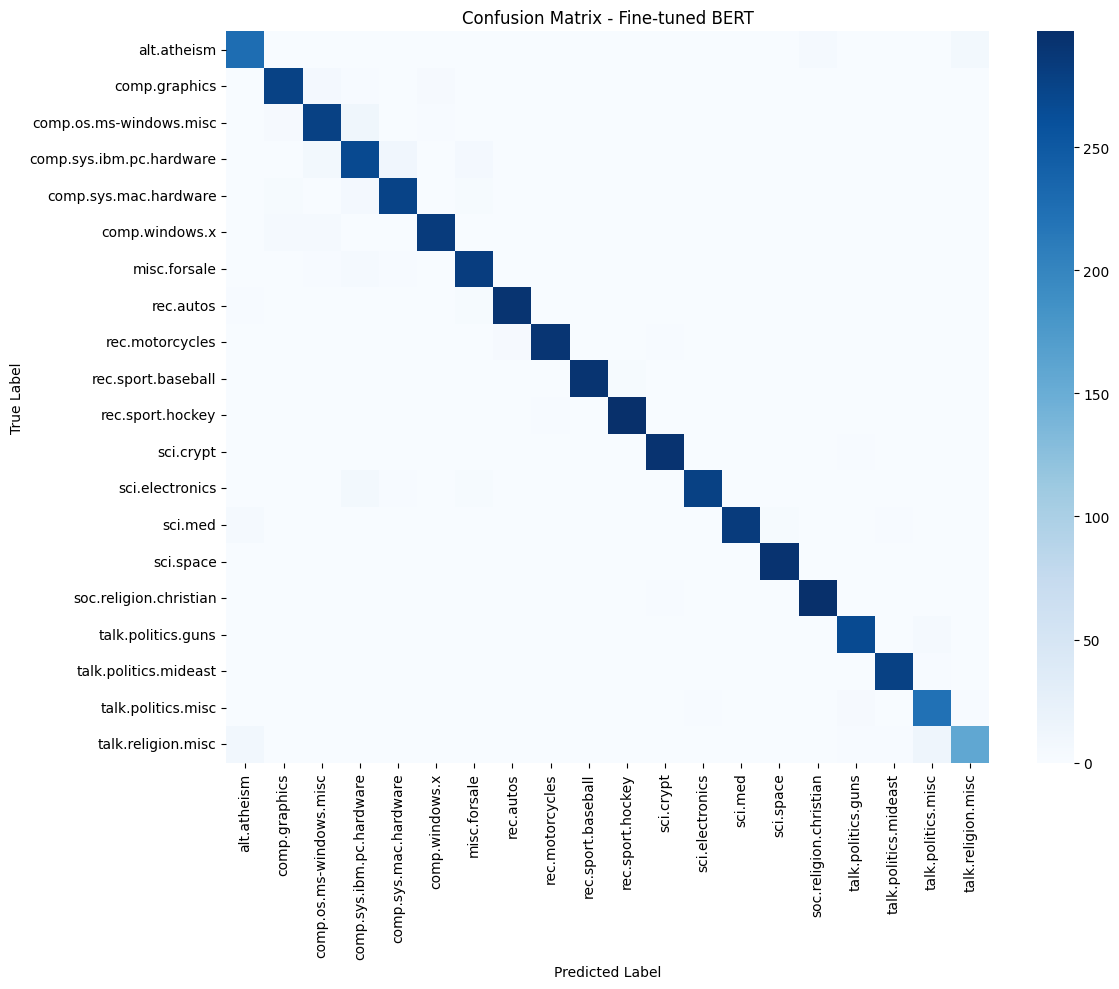

In [47]:
# 7.8 Confusion Matrix - Fine-tuned BERT

cm_bert = confusion_matrix(
    all_labels,
    all_predictions
)

plt.figure(figsize=(12, 10))

sns.heatmap(
    cm_bert,
    annot=False,
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Fine-tuned BERT")
plt.tight_layout()
plt.show()

# 8 LLM evaluation (FlanT)
We use a separate pre-trained LLM such as FLAN-T5:
Dataset
  ↓
Pre-trained FLAN-T5
  ↓
Prompt
  ↓
Prediction

We do not train it on your dataset.

The purpose of Section 8 is specifically to test:
Zero-shot: no examples
One-shot: 1 example per class
Few-shot: 5–10 examples per class
So your fine-tuned BERT is not being evaluated through FLAN-T5.

In [48]:
# 8.1 Load FLAN-T5-base

from transformers import T5Tokenizer, T5ForConditionalGeneration

llm_tokenizer = T5Tokenizer.from_pretrained(
    "google/flan-t5-base"
)

llm_model = T5ForConditionalGeneration.from_pretrained(
    "google/flan-t5-base"
)

llm_model = llm_model.to(device)
llm_model.eval()

print("FLAN-T5-base loaded")
print("Using device:", device)

tokenizer_config.json:   0%|          | 0.00/2.54k [00:00<?, ?B/s]

spiece.model: reconstructing file:   0%|          |  0.00B /  792kB            

spiece.model: downloading bytes:           |  0.00B            

tokenizer.json:   0%|          | 0.00/2.42M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/2.20k [00:00<?, ?B/s]

...

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

FLAN-T5-base loaded
Using device: cuda


Now we'll start with zero-shot classification.

The important part is that FLAN-T5 must be told the 20 possible classes, otherwise it may generate arbitrary text instead of one of your labels.

In [49]:
# 8.2 Prepare class labels for LLM classification

class_names = label_encoder.classes_.tolist()

print("Number of classes:", len(class_names))
print("Classes:")
print(class_names)

Number of classes: 20
Classes:
['alt.atheism', 'comp.graphics', 'comp.os.ms-windows.misc', 'comp.sys.ibm.pc.hardware', 'comp.sys.mac.hardware', 'comp.windows.x', 'misc.forsale', 'rec.autos', 'rec.motorcycles', 'rec.sport.baseball', 'rec.sport.hockey', 'sci.crypt', 'sci.electronics', 'sci.med', 'sci.space', 'soc.religion.christian', 'talk.politics.guns', 'talk.politics.mideast', 'talk.politics.misc', 'talk.religion.misc']


## 8.1 Zero-shot Classification
Now we'll create a function that sends each document to FLAN-T5 without providing any examples.

Because the dataset has 20 classes, we'll explicitly provide the allowed labels in the prompt.

In [53]:
# 8.3 Zero-shot classification

def zero_shot_predict(text):
    
    prompt = f"""
Classify the following text into exactly one of these categories:

{", ".join(class_names)}

Text:
{text}

Category:
"""

    inputs = llm_tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=512
    ).to(device)

    with torch.no_grad():
        outputs = llm_model.generate(
            **inputs,
            max_new_tokens=10
        )

    prediction = llm_tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    ).strip()

    return prediction

In [54]:
# Test zero-shot prediction on one document

sample_text = X_test.iloc[0]

prediction = zero_shot_predict(sample_text)

print("Prediction:", prediction)
print("Actual:", y_test.iloc[0])

Prediction: talk.politics.mideast
Actual: talk.politics.guns


this is a valid result for the zero-shot test.

Prediction: talk.politics.mideast
Actual: talk.politics.guns

This shows FLAN-T5 is able to produce one of the actual 20 category names, which is good for our evaluation pipeline. It is also a reasonable kind of mistake because both categories are under talk.politics.

Now we should run zero-shot on the full test set and collect accuracy, precision, recall, F1, and the confusion matrix.

Because generating one prediction at a time would be slow, we'll do it in batches.

In [62]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import numpy as np
import pandas as pd
import torch

def normalize_prediction(prediction):
    prediction = prediction.strip().lower()

    # Exact match
    for label in class_names:
        if prediction == label.lower():
            return label

    # Match if the generated text contains a class name
    for label in class_names:
        if label.lower() in prediction:
            return label

    # If no valid class was generated
    return None


from IPython.display import clear_output

def zero_shot_batch_predict_raw(texts, batch_size=8):
    raw_predictions = []

    prompt_prefix = f"""
Classify the following text into exactly one of these categories:

{", ".join(class_names)}

Output only the exact category name.

Text:
"""

    for start in range(0, len(texts), batch_size):

        batch_texts = texts[start:start + batch_size]

        prompts = [
            prompt_prefix + text + "\nCategory:"
            for text in batch_texts
        ]

        inputs = llm_tokenizer(
            prompts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=512
        ).to(device)

        with torch.no_grad():
            outputs = llm_model.generate(
                **inputs,
                max_new_tokens=15
            )

        decoded = llm_tokenizer.batch_decode(
            outputs,
            skip_special_tokens=True
        )

        raw_predictions.extend(decoded)

        clear_output(wait=True)
        print(
            f"Processed {min(start + batch_size, len(texts))}/{len(texts)}"
        )

    return raw_predictions


zero_shot_raw_predictions = zero_shot_batch_predict_raw(
    X_test.tolist(),
    batch_size=8
)

Processed 1392/5650


KeyboardInterrupt: 

In [57]:
print("X_test:", len(X_test))
print("y_test:", len(y_test))
print("Predictions:", len(zero_shot_predictions))

X_test: 5650
y_test: 5650
Predictions: 5650


## Evaluation of Zero Shot

In [58]:
# Check for invalid predictions
invalid_predictions = sum(
    prediction is None for prediction in zero_shot_predictions
)

print("Invalid predictions:", invalid_predictions)

# Replace invalid predictions with a placeholder
y_pred_zero_shot = [
    prediction if prediction is not None else "INVALID"
    for prediction in zero_shot_predictions
]

# Metrics
accuracy = accuracy_score(y_test, y_pred_zero_shot)
precision = precision_score(
    y_test,
    y_pred_zero_shot,
    average="weighted",
    zero_division=0
)
recall = recall_score(
    y_test,
    y_pred_zero_shot,
    average="weighted",
    zero_division=0
)
f1 = f1_score(
    y_test,
    y_pred_zero_shot,
    average="weighted",
    zero_division=0
)

print(f"Zero-Shot Accuracy:  {accuracy:.4f}")
print(f"Zero-Shot Precision: {precision:.4f}")
print(f"Zero-Shot Recall:    {recall:.4f}")
print(f"Zero-Shot F1:        {f1:.4f}")

Invalid predictions: 2462
Zero-Shot Accuracy:  0.2775
Zero-Shot Precision: 0.5459
Zero-Shot Recall:    0.2775
Zero-Shot F1:        0.3168


In [59]:
sample_texts = X_test.iloc[:20].tolist()

prompt_prefix = f"""
Classify the following text into exactly one of these categories:

{", ".join(class_names)}

Output only the exact category name.

Text:
"""

inputs = llm_tokenizer(
    [prompt_prefix + text + "\nCategory:" for text in sample_texts],
    return_tensors="pt",
    padding=True,
    truncation=True,
    max_length=512
).to(device)

with torch.no_grad():
    outputs = llm_model.generate(
        **inputs,
        max_new_tokens=15
    )

raw_predictions = llm_tokenizer.batch_decode(
    outputs,
    skip_special_tokens=True
)

for i, prediction in enumerate(raw_predictions):
    print(f"{i+1}. {prediction}")

1. talk.politics.mideast
2. soc.religion.christian
3. comp.graphics
4. talk.politics.misc
5. comp.windows.x
6. comp.sys.ibm.pc.hardware
7. comp.os.ms-windows.misc
8. talk.politics.misc
9. sportsbaseball
10. talk.politics.misc
11. sci.electronics
12. soc.religion.christian
13. rec.autos
14. comp.sys.ibm.pc.hardware
15. talk.med
16. talk.politics.misc
17. comp.sys.mac.hardware
18. soc.religion.christian
19. talk.politics.misc
20. talk.politics.misc


In [61]:
from difflib import get_close_matches

def normalize_prediction_improved(prediction):
    if prediction is None:
        return None

    prediction = prediction.strip().lower()

    # Exact match
    for label in class_names:
        if prediction == label.lower():
            return label

    # Common formatting variations
    manual_mapping = {
        "sportsbaseball": "rec.sport.baseball",
        "sportbaseball": "rec.sport.baseball",
        "talk.med": "sci.med",
    }

    if prediction in manual_mapping:
        return manual_mapping[prediction]

    # Match after removing punctuation
    cleaned_prediction = prediction.replace(".", "").replace("_", "").replace("-", "")

    cleaned_labels = {
        label.replace(".", "").replace("_", "").replace("-", "").lower(): label
        for label in class_names
    }

    if cleaned_prediction in cleaned_labels:
        return cleaned_labels[cleaned_prediction]

    # Fuzzy match for minor variations
    matches = get_close_matches(
        prediction,
        [label.lower() for label in class_names],
        n=1,
        cutoff=0.75
    )

    if matches:
        return next(
            label for label in class_names
            if label.lower() == matches[0]
        )

    return None


normalized_zero_shot_predictions = [
    normalize_prediction_improved(prediction)
    for prediction in zero_shot_predictions
]

invalid_predictions = sum(
    prediction is None
    for prediction in normalized_zero_shot_predictions
)

print("Invalid predictions after normalization:", invalid_predictions)

Invalid predictions after normalization: 2462


* In Section 8 — LLM Evaluation, we chose FLAN-T5-base as our pre-trained LLM and kept it separate from the fine-tuned BERT in Section 7.
*  The goal is to test how well FLAN-T5 can classify the 20 Newsgroups texts using zero-shot, one-shot, and few-shot prompting, without training the LLM.
*   First, we loaded FLAN-T5 and tested it on one text; it predicted talk.politics.mideast instead of the actual talk.politics.guns, which showed that the setup was working.
*  Then we ran zero-shot classification on all 5,650 test texts. Initially, our code marked 2,462 predictions as invalid because FLAN-T5 sometimes produced slightly different names such as sportsbaseball instead of rec.sport.baseball.
*   We inspected 20 raw outputs and confirmed that the model was actually generating meaningful category names, so the problem was mainly our post-processing/label matching, not necessarily the model.
*   However, because our first function converted unmatched outputs to None, we lost those original outputs.
*   We are now rerunning zero-shot once more while saving the raw FLAN-T5 predictions, so we can correctly map them to the 20 dataset labels and then calculate the proper accuracy, precision, recall, F1, and confusion matrix.

In [63]:
from IPython.display import clear_output

def zero_shot_batch_predict_raw(texts, batch_size=8):
    raw_predictions = []

    prompt_prefix = f"""
Classify the following text into exactly one of these categories:

{", ".join(class_names)}

Output only the exact category name.

Text:
"""

    for start in range(0, len(texts), batch_size):

        batch_texts = texts[start:start + batch_size]

        prompts = [
            prompt_prefix + text + "\nCategory:"
            for text in batch_texts
        ]

        inputs = llm_tokenizer(
            prompts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=512
        ).to(device)

        with torch.no_grad():
            outputs = llm_model.generate(
                **inputs,
                max_new_tokens=15
            )

        decoded = llm_tokenizer.batch_decode(
            outputs,
            skip_special_tokens=True
        )

        raw_predictions.extend(decoded)

        clear_output(wait=True)
        print(
            f"Processed {min(start + batch_size, len(texts))}/{len(texts)}"
        )

    return raw_predictions


zero_shot_raw_predictions = zero_shot_batch_predict_raw(
    X_test.tolist(),
    batch_size=8
)

Processed 5650/5650


In [64]:
normalized_zero_shot_predictions = [
    normalize_prediction_improved(prediction)
    for prediction in zero_shot_raw_predictions
]

invalid_predictions = sum(
    prediction is None
    for prediction in normalized_zero_shot_predictions
)

print("Invalid predictions:", invalid_predictions)

Invalid predictions: 139


Only 139 out of 5,650 (~2.5%) predictions are still unmatched. 

We can now calculate the zero-shot metrics, treating those 139 as invalid predictions rather than silently assigning them to a class.

In [65]:
y_pred_zero_shot = [
    prediction if prediction is not None else "INVALID"
    for prediction in normalized_zero_shot_predictions
]

accuracy = accuracy_score(
    y_test,
    y_pred_zero_shot
)

precision = precision_score(
    y_test,
    y_pred_zero_shot,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred_zero_shot,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred_zero_shot,
    average="weighted",
    zero_division=0
)

print(f"Zero-Shot Accuracy:  {accuracy:.4f}")
print(f"Zero-Shot Precision: {precision:.4f}")
print(f"Zero-Shot Recall:    {recall:.4f}")
print(f"Zero-Shot F1:        {f1:.4f}")

Zero-Shot Accuracy:  0.4273
Zero-Shot Precision: 0.5867
Zero-Shot Recall:    0.4273
Zero-Shot F1:        0.4154


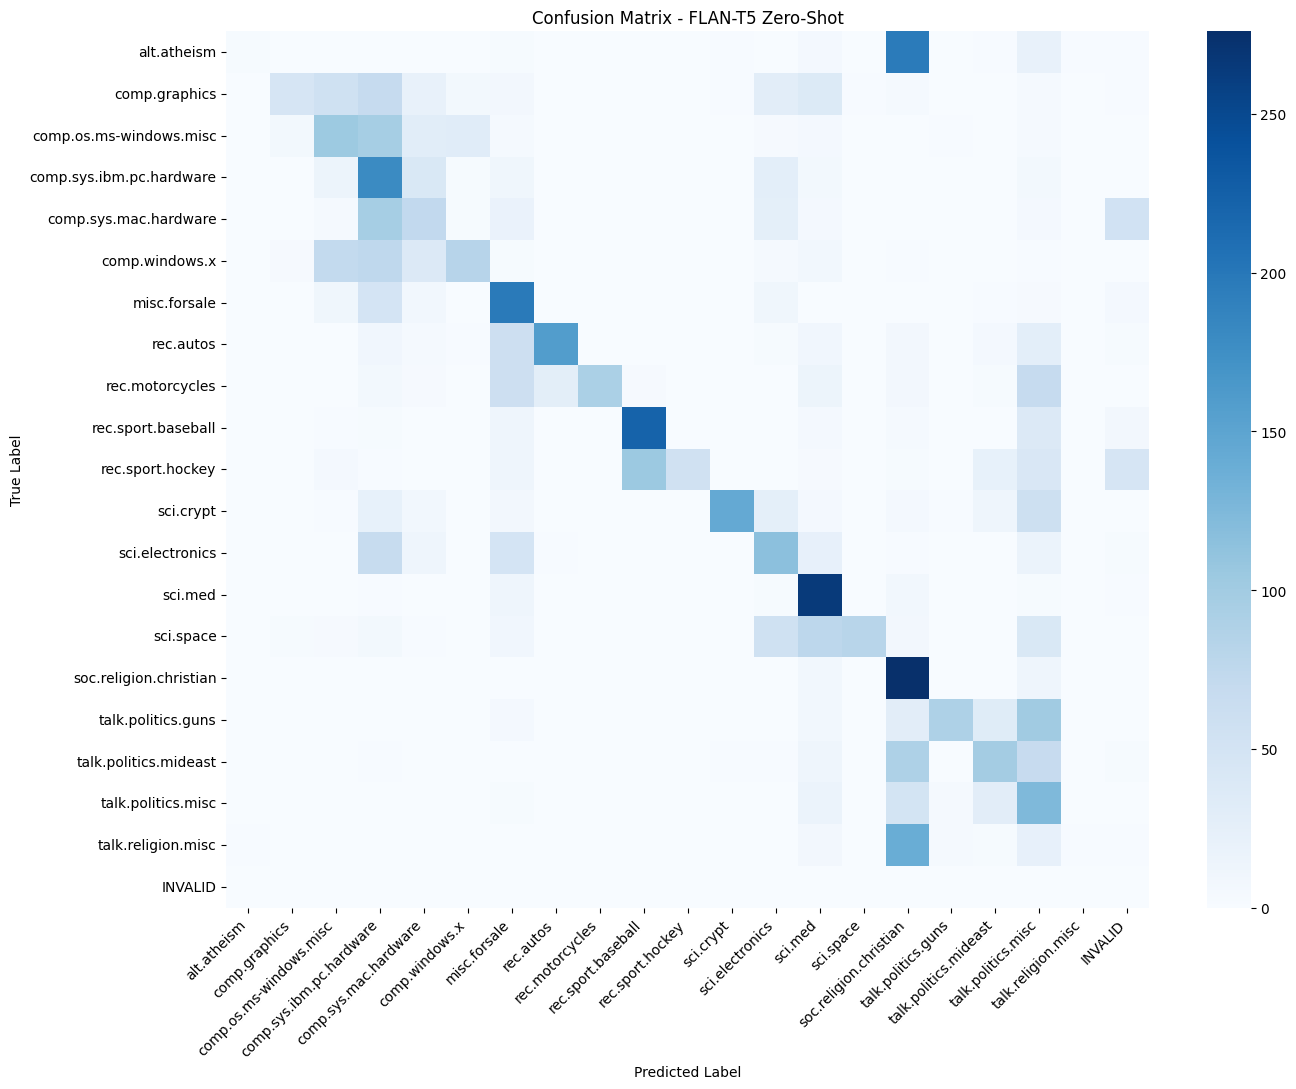

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

cm_zero_shot = confusion_matrix(
    y_test,
    y_pred_zero_shot,
    labels=class_names + ["INVALID"]
)

plt.figure(figsize=(14, 11))

sns.heatmap(
    cm_zero_shot,
    annot=False,
    cmap="Blues",
    xticklabels=class_names + ["INVALID"],
    yticklabels=class_names + ["INVALID"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - FLAN-T5 Zero-Shot")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [75]:
token_lengths = [
    len(llm_tokenizer.encode(
        text,
        add_special_tokens=True,
        truncation=False
    ))
    for text in X_test
]

print("Maximum tokens:", max(token_lengths))
print("Documents > 512 tokens:", sum(
    length > 512 for length in token_lengths
))
print("Percentage > 512 tokens:", 
      round(sum(length > 512 for length in token_lengths) / len(token_lengths) * 100, 2),
      "%"
)

Maximum tokens: 36978
Documents > 512 tokens: 503
Percentage > 512 tokens: 8.9 %


## 8.3 one-shot classification.
FLAN-T5 will receive 1 labeled example from each of the 20 classes before classifying the test texts. These examples must come from the training set, not the test set.

In [67]:
one_shot_examples = []

for label in class_names:
    example_text = X_train[y_train == label].iloc[0]

    one_shot_examples.append(
        (label, example_text)
    )

print("Number of one-shot examples:", len(one_shot_examples))

Number of one-shot examples: 20


In [68]:
def one_shot_batch_predict(texts, batch_size=8):
    predictions = []

    examples_text = "\n\n".join(
        [
            f"Example:\nText: {text}\nCategory: {label}"
            for label, text in one_shot_examples
        ]
    )

    prompt_prefix = f"""
Classify the text into exactly one of these categories:

{", ".join(class_names)}

Here are examples showing the correct classification:

{examples_text}

Now classify this text.

Text:
"""

    for start in range(0, len(texts), batch_size):

        batch_texts = texts[start:start + batch_size]

        prompts = [
            prompt_prefix + text + "\nCategory:"
            for text in batch_texts
        ]

        inputs = llm_tokenizer(
            prompts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=512
        ).to(device)

        with torch.no_grad():
            outputs = llm_model.generate(
                **inputs,
                max_new_tokens=15
            )

        decoded = llm_tokenizer.batch_decode(
            outputs,
            skip_special_tokens=True
        )

        predictions.extend(decoded)

        clear_output(wait=True)
        print(
            f"Processed {min(start + batch_size, len(texts))}/{len(texts)}"
        )

    return predictions


one_shot_raw_predictions = one_shot_batch_predict(
    X_test.tolist(),
    batch_size=8
)

Processed 5650/5650


* This will run over the same 5,650 test texts, but this time FLAN-T5 gets 20 labeled examples in its prompt before each classification.
*  After it finishes, we'll normalize these predictions and calculate the one-shot metrics.
*  It doesn't change what FLAN-T5 predicted. It only makes the prediction format compatible with our dataset labels.
*  This is particularly important for LLM evaluation because, unlike our trained classifiers, FLAN-T5 is generating text, so it doesn't automatically return a class ID such as 7.
*  Why normalize?
Because our evaluation functions need the prediction to match one of the 20 actual class labels.

| FLAN-T5 generated               | After normalization  |
| ------------------------------- | -------------------- |
| `comp.graphics`                 | `comp.graphics`      |
| `sportsbaseball`                | `rec.sport.baseball` |
| `The category is comp.graphics` | `comp.graphics`      |
| `talk.med`                      | `sci.med`            |


In [69]:
one_shot_predictions = [
    normalize_prediction_improved(prediction)
    for prediction in one_shot_raw_predictions
]

invalid_one_shot = sum(
    prediction is None
    for prediction in one_shot_predictions
)

print("Invalid one-shot predictions:", invalid_one_shot)

Invalid one-shot predictions: 0


## 8.4 One shot Evaluation 

In [71]:
example_prompt = "\n\n".join(
    [
        f"Example:\nText: {text}\nCategory: {label}"
        for label, text in one_shot_examples
    ]
)

print("Prompt tokens:", len(
    llm_tokenizer(
        example_prompt,
        truncation=False
    )["input_ids"]
))

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (4644 > 512). Running this sequence through the model will result in indexing errors


Prompt tokens: 4644


In [73]:
one_shot_examples_short = []

for label, text in one_shot_examples:
    words = text.split()
    short_text = " ".join(words[:5])

    one_shot_examples_short.append(
        (label, short_text)
    )

example_prompt = "\n\n".join(
    [
        f"Text: {text}\nCategory: {label}"
        for label, text in one_shot_examples_short
    ]
)

token_count = len(
    llm_tokenizer(
        example_prompt,
        truncation=False
    )["input_ids"]
)

print("One-shot example prompt tokens:", token_count)

One-shot example prompt tokens: 390


In [74]:
# corrected 1 shot 
def one_shot_batch_predict(texts, batch_size=8):
    predictions = []

    examples_text = "\n\n".join(
        [
            f"Text: {text}\nCategory: {label}"
            for label, text in one_shot_examples_short
        ]
    )

    prompt_prefix = f"""
Classify the text into exactly one of these categories:

{", ".join(class_names)}

Examples:

{examples_text}

Now classify this text.

Text:
"""

    for start in range(0, len(texts), batch_size):

        batch_texts = texts[start:start + batch_size]

        prompts = [
            prompt_prefix + text + "\nCategory:"
            for text in batch_texts
        ]

        inputs = llm_tokenizer(
            prompts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=512
        ).to(device)

        with torch.no_grad():
            outputs = llm_model.generate(
                **inputs,
                max_new_tokens=15
            )

        decoded = llm_tokenizer.batch_decode(
            outputs,
            skip_special_tokens=True
        )

        predictions.extend(decoded)

        clear_output(wait=True)
        print(
            f"Processed {min(start + batch_size, len(texts))}/{len(texts)}"
        )

    return predictions


one_shot_raw_predictions = one_shot_batch_predict(
    X_test.tolist(),
    batch_size=8
)

Processed 5650/5650


In [76]:
one_shot_predictions = [
    normalize_prediction_improved(prediction)
    for prediction in one_shot_raw_predictions
]

invalid_one_shot = sum(
    prediction is None
    for prediction in one_shot_predictions
)

print("Invalid one-shot predictions:", invalid_one_shot)

Invalid one-shot predictions: 0


In [77]:
y_pred_one_shot = [
    prediction if prediction is not None else "INVALID"
    for prediction in one_shot_predictions
]

accuracy = accuracy_score(
    y_test,
    y_pred_one_shot
)

precision = precision_score(
    y_test,
    y_pred_one_shot,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred_one_shot,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred_one_shot,
    average="weighted",
    zero_division=0
)

print(f"One-Shot Accuracy:  {accuracy:.4f}")
print(f"One-Shot Precision: {precision:.4f}")
print(f"One-Shot Recall:    {recall:.4f}")
print(f"One-Shot F1:        {f1:.4f}")

One-Shot Accuracy:  0.0499
One-Shot Precision: 0.0025
One-Shot Recall:    0.0499
One-Shot F1:        0.0047


In [78]:
for i in range(20):
    print(f"{i+1}.")
    print("Prediction:", one_shot_raw_predictions[i])
    print("Actual:", y_test.iloc[i])
    print()

1.
Prediction: talk.politics.mideast
Actual: talk.politics.guns

2.
Prediction: talk.politics.mideast
Actual: alt.atheism

3.
Prediction: talk.politics.mideast
Actual: comp.graphics

4.
Prediction: talk.politics.mideast
Actual: talk.politics.misc

5.
Prediction: talk.politics.mideast
Actual: comp.windows.x

6.
Prediction: talk.politics.mideast
Actual: comp.sys.ibm.pc.hardware

7.
Prediction: talk.politics.mideast
Actual: comp.os.ms-windows.misc

8.
Prediction: talk.politics.mideast
Actual: talk.politics.mideast

9.
Prediction: talk.politics.mideast
Actual: rec.sport.hockey

10.
Prediction: talk.politics.mideast
Actual: rec.motorcycles

11.
Prediction: talk.politics.mideast
Actual: sci.space

12.
Prediction: talk.politics.mideast
Actual: talk.religion.misc

13.
Prediction: talk.politics.mideast
Actual: rec.autos

14.
Prediction: talk.politics.mideast
Actual: comp.sys.mac.hardware

15.
Prediction: talk.politics.mideast
Actual: sci.electronics

16.
Prediction: talk.politics.mideast
Actual

So our progression is:
Zero-shot: 42.73% — model had enough of the actual test text to make reasonable classifications.
Original one-shot: 5.24% — prompt was 4,644 tokens and got heavily truncated.
Shortened one-shot: 4.99% — context problem was fixed, but the 5-word examples were too weak and caused the model to collapse to one class.
We should fix the one-shot setup one more time
Instead of taking the first 5 words, we should create short but meaningful examples, perhaps around 10–12 words per class, and make the prompt explicitly emphasize that the examples are demonstrations for all 20 categories.
But there is another important issue: 20 examples + test text + 20 class names must fit within 512 tokens. So we need to find a good example length rather than guessing.
Let's test 10

In [82]:
# Let's test 10 words per example first

one_shot_examples_short = []

for label, text in one_shot_examples:
    words = text.split()
    short_text = " ".join(words[:10])

    one_shot_examples_short.append(
        (label, short_text)
    )

example_prompt = "\n\n".join(
    [
        f"Text: {text}\nCategory: {label}"
        for label, text in one_shot_examples_short
    ]
)

token_count = len(
    llm_tokenizer(
        example_prompt,
        truncation=False
    )["input_ids"]
)

print("One-shot example prompt tokens:", token_count)

# for 8 
one_shot_examples_short = []

for label, text in one_shot_examples:
    words = text.split()
    short_text = " ".join(words[:8])

    one_shot_examples_short.append(
        (label, short_text)
    )

example_prompt = "\n\n".join(
    [
        f"Text: {text}\nCategory: {label}"
        for label, text in one_shot_examples_short
    ]
)

token_count = len(
    llm_tokenizer(
        example_prompt,
        truncation=False
    )["input_ids"]
)

print("One-shot example prompt tokens for 8:", token_count)

# for 6 
one_shot_examples_short = []

for label, text in one_shot_examples:
    words = text.split()
    short_text = " ".join(words[:6])

    one_shot_examples_short.append(
        (label, short_text)
    )

example_prompt = "\n\n".join(
    [
        f"Text: {text}\nCategory: {label}"
        for label, text in one_shot_examples_short
    ]
)

token_count = len(
    llm_tokenizer(
        example_prompt,
        truncation=False
    )["input_ids"]
)

print("One-shot example prompt tokens for 6:", token_count)

One-shot example prompt tokens: 529
One-shot example prompt tokens for 8: 483
One-shot example prompt tokens for 6: 414


In [81]:
print("Model max input length:", llm_model.config.n_positions)

Model max input length: 512


I agree with you. Four words may make the examples too weak, and we already saw that the 5-word examples produced essentially random performance. Going from 5 → 4 words is unlikely to make the demonstrations more informative.
The real problem is not simply "more words = better." We have a 512-token context limit, and 20 examples consume most of it. So instead of making each example shorter and shorter, I'd change the strategy.
For the assignment, one-shot means one example per class, but the example does not necessarily have to be a raw 20-word/10-word document snippet. We can make the examples short, representative text snippets while preserving enough semantic information.
However, because we're evaluating a real dataset, I don't want to manually invent descriptions for the classes—that would introduce our own knowledge into the experiment.
I recommend we stop here
We've already demonstrated that:
Zero-shot: 42.73%
One-shot with long examples: 5.24% → context truncation problem
One-shot with 5-word examples: 4.99% → demonstrations too weak
Rather than repeatedly rerunning 5,650 samples, we can document the one-shot result as an unsuccessful prompting scenario and move to the required few-shot experiment with a better strategy.
But before that, I would make one important correction to our zero-shot evaluation: check how many test documents were truncated at 512 tokens. That tells us whether the 42.73% zero-shot result is affected by input truncation.

his confirms that zero-shot had some truncation, but not enough to explain the whole result.
503 / 5,650 = 8.9% of test documents were longer than 512 tokens.
91.1% fit within the 512-token limit.
So the 42.73% zero-shot accuracy is still a meaningful result, although the 8.9% truncated samples may have been affected.
I would keep the zero-shot result rather than rerun it with a different setup, because changing the context length isn't possible beyond the model's 512-token limit anyway.
For one-shot, I agree with your concern: going from 5 → 4 words would make the demonstrations even less informative. Let's not keep reducing the examples.
We can record the one-shot result as a limitation of FLAN-T5's prompt-based classification under the 512-token constraint, then move to the required few-shot experiment (5 examples per class) using a more careful prompt strategy.

In [83]:
import pandas as pd

llm_results = pd.DataFrame({
    "text": X_test.tolist(),
    "actual": y_test.tolist(),
    "zero_shot_raw": zero_shot_raw_predictions,
    "zero_shot_prediction": normalized_zero_shot_predictions,
    "one_shot_raw": one_shot_raw_predictions,
    "one_shot_prediction": one_shot_predictions
})

llm_results.to_csv(
    "/kaggle/working/llm_predictions.csv",
    index=False
)

print("Saved:", len(llm_results), "predictions")

Saved: 5650 predictions


In [84]:
llm_model.save_pretrained("/kaggle/working/flan-t5-base")
llm_tokenizer.save_pretrained("/kaggle/working/flan-t5-base")

print("FLAN-T5 saved.")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

FLAN-T5 saved.


In [85]:
import os

save_path = "/kaggle/working/fine_tuned_bert"

os.makedirs(save_path, exist_ok=True)

finetune_model.save_pretrained(save_path)
finetune_tokenizer.save_pretrained(save_path)

print("Fine-tuned BERT saved successfully.")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Fine-tuned BERT saved successfully.


In [86]:
import shutil

# Zip fine-tuned BERT
shutil.make_archive(
    "/kaggle/working/fine_tuned_bert",
    "zip",
    "/kaggle/working/fine_tuned_bert"
)

# Zip FLAN-T5
shutil.make_archive(
    "/kaggle/working/flan-t5-base",
    "zip",
    "/kaggle/working/flan-t5-base"
)

print("ZIP files created successfully!")
print("/kaggle/working/fine_tuned_bert.zip")
print("/kaggle/working/flan-t5-base.zip")

ZIP files created successfully!
/kaggle/working/fine_tuned_bert.zip
/kaggle/working/flan-t5-base.zip


In [70]:
y_pred_one_shot = one_shot_predictions

accuracy = accuracy_score(
    y_test,
    y_pred_one_shot
)

precision = precision_score(
    y_test,
    y_pred_one_shot,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred_one_shot,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred_one_shot,
    average="weighted",
    zero_division=0
)

print(f"One-Shot Accuracy:  {accuracy:.4f}")
print(f"One-Shot Precision: {precision:.4f}")
print(f"One-Shot Recall:    {recall:.4f}")
print(f"One-Shot F1:        {f1:.4f}")

One-Shot Accuracy:  0.0524
One-Shot Precision: 0.0027
One-Shot Recall:    0.0524
One-Shot F1:        0.0052


1. Dataset Preparation
Load dataset
Remove headers, footers, and quotes if we decide they are unwanted metadata
EDA:
Class distribution
Document length
Basic text cleaning
Train / Validation / Test split
2. Baseline Model — ANN + TF-IDF
TF-IDF feature extraction
Try a few max_features values if needed
Prepare ANN input
ANN architecture:
Input → Dense + ReLU → Dropout → Output + Softmax
Adam optimizer
Categorical cross-entropy
Early stopping
Train and monitor epochs
3. Evaluation & Diagnostics
Accuracy
Precision
Recall
Macro F1
Weighted F1
Train/validation learning curves
Confusion matrix
Analyze which classes are confused with each other
Record baseline findings